In [1]:
import pickle
import bioframe
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
from matplotlib import pyplot as plt

Continued: <br>
/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Bond_et_al_2023.ipynb <br>

### Upset plot of all 7 subsets (R kernel) (old method)

In [1]:
# R kernel
library(UpSetR)
library(grid)
library(stringr)

Warning message:
“package ‘UpSetR’ was built under R version 4.0.5”
Warning message:
“package ‘stringr’ was built under R version 4.0.5”


In [2]:
df1=read.table(file = '/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/union_dot_list_of_Bond_et_al_2023_5kb_old_method.txt', sep = '\t', header = TRUE)
upsetplot_input=table(df1$sample_name)

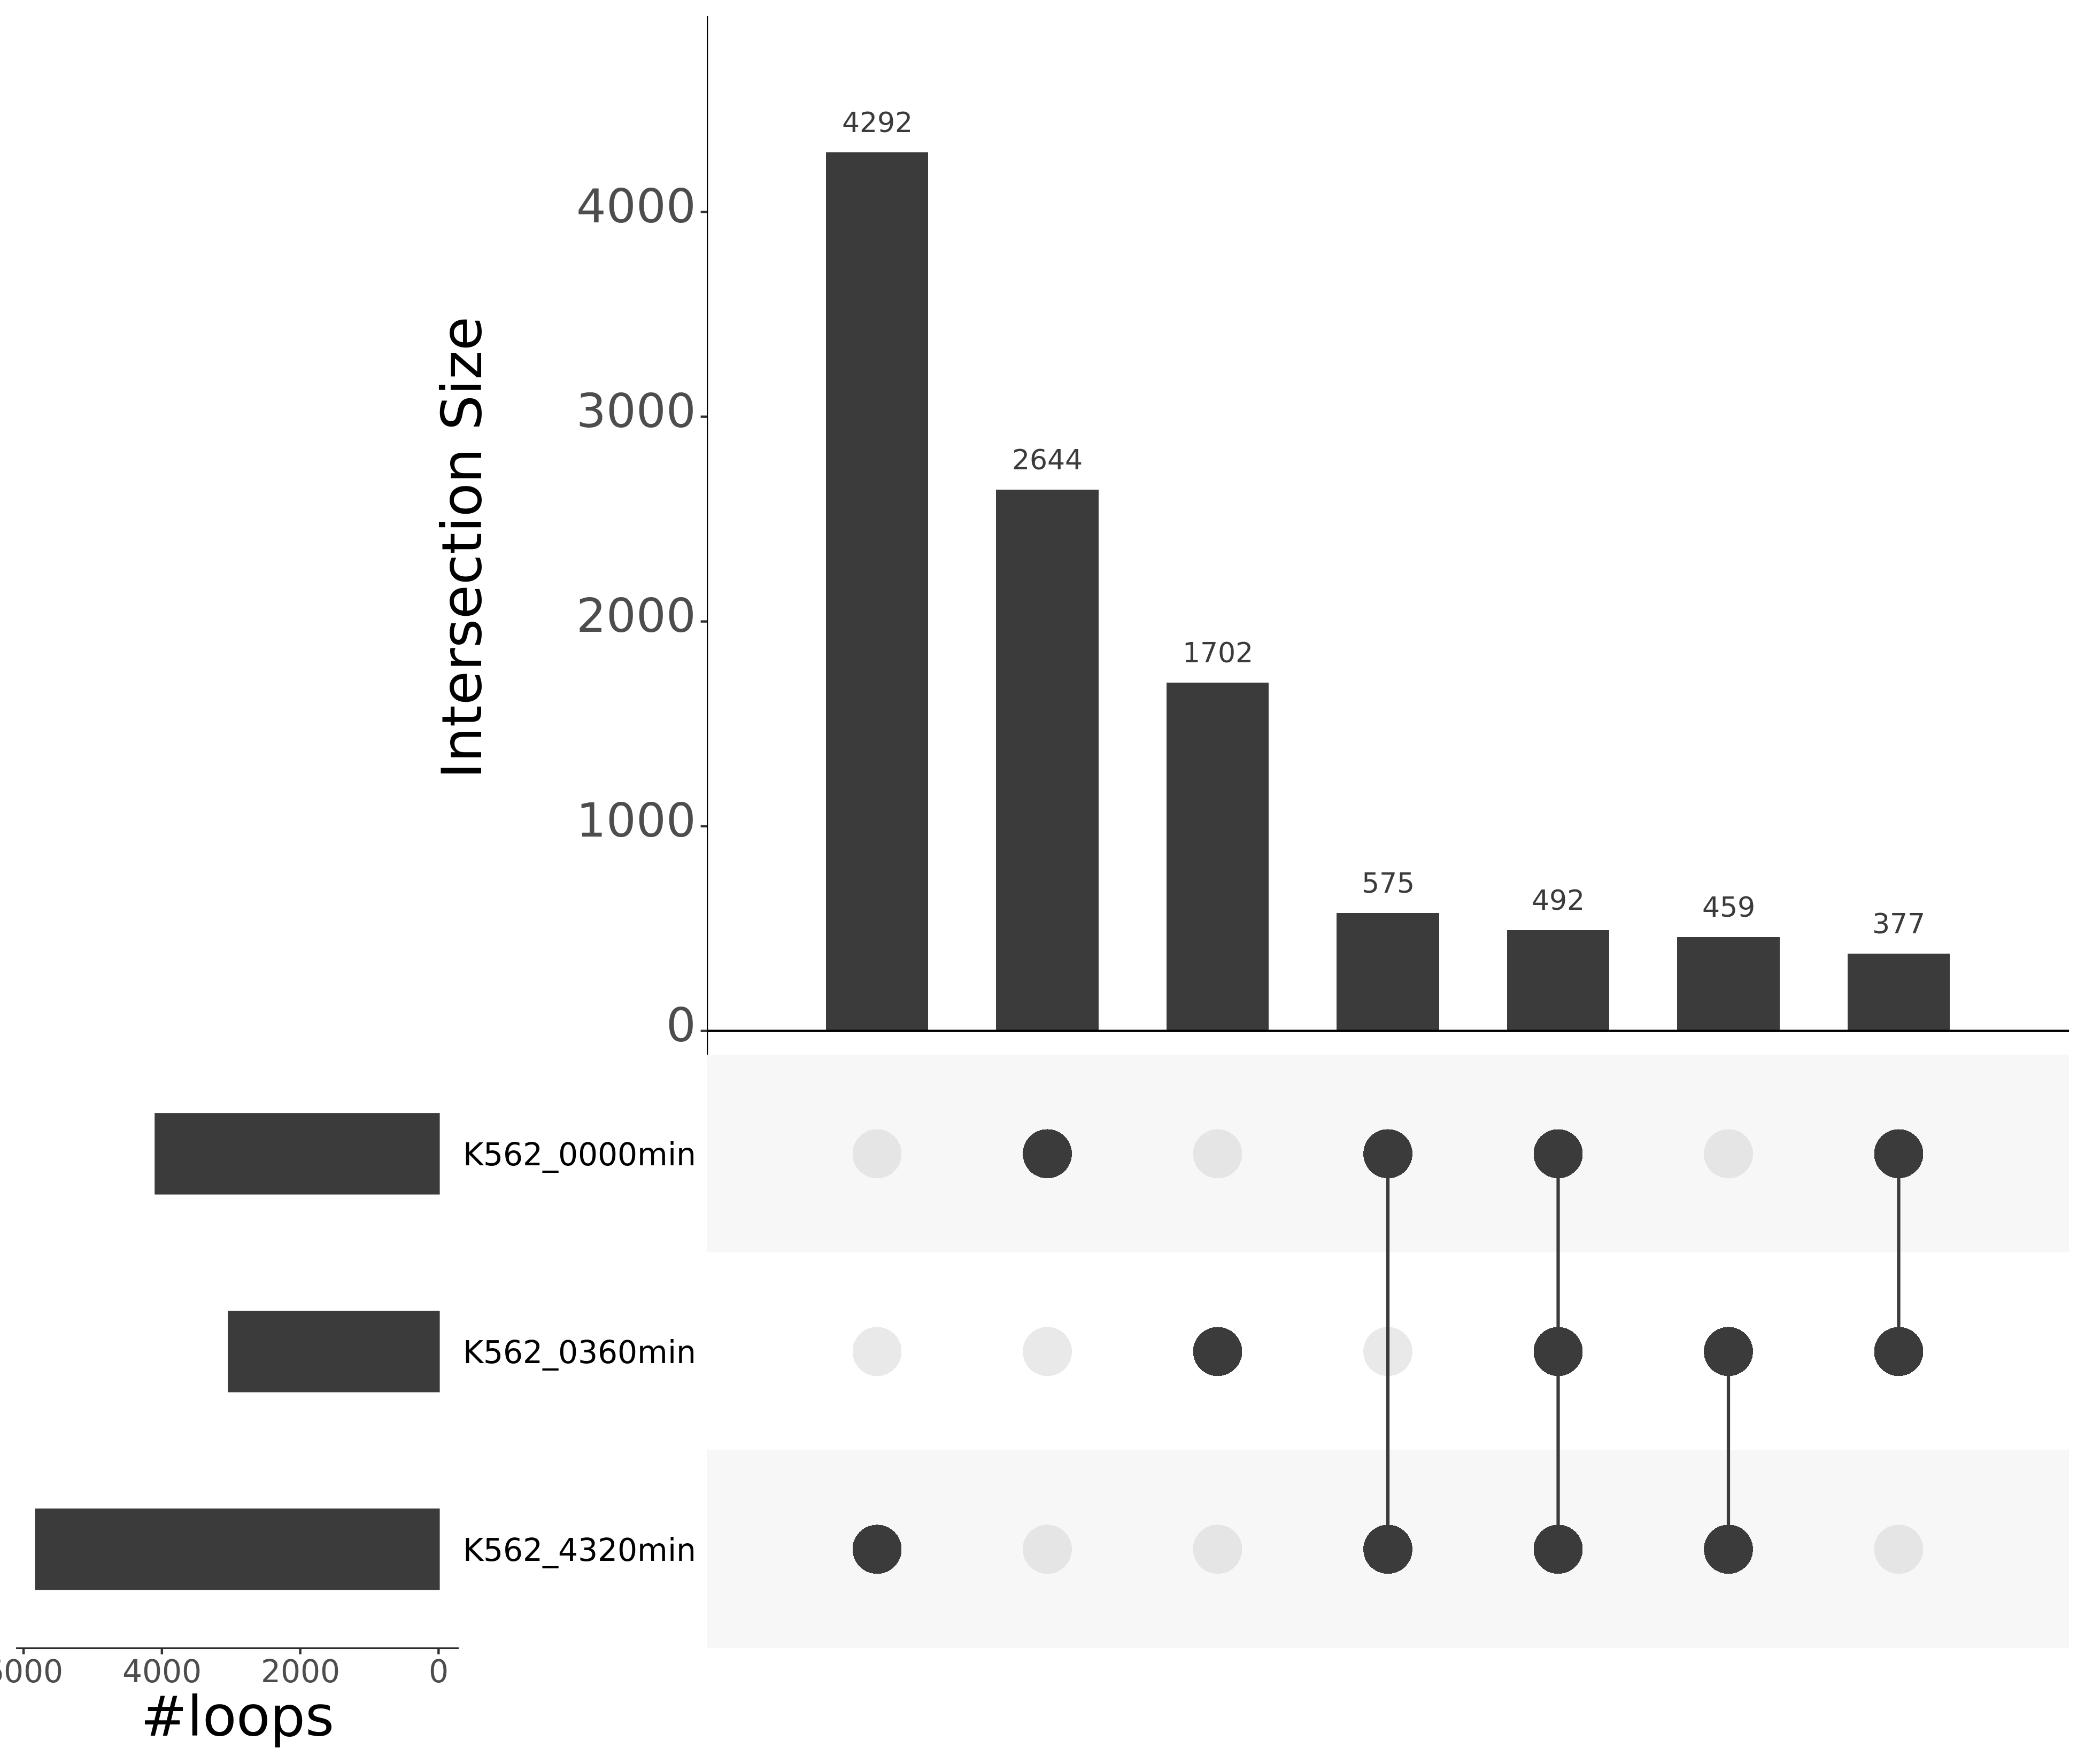

In [3]:
options(repr.plot.width = 13, repr.plot.height = 11, repr.plot.res = 300)
upset(fromExpression(upsetplot_input), 
      nintersects = 7,
      keep.order = T,
      order.by = 'freq',
      text.scale=c(3, 3, 3, 2, 2, 2),
      point.size=10,
      mb.ratio = c(0.6, 0.4),
      sets = c('K562_4320min',
               'K562_0360min',
               'K562_0000min'),
      sets.x.label = "#loops"#x axis small plot
      )
# grid.text("Upset plots of the union loop list called\nfrom each individual libraries (5kb resolution)", x = 0.7, y = 0.97, gp = gpar(fontsize = 15))


In [4]:
# Total number of loops called from three time points
nrow(df1) - sum(df1$sample_name == 'MEGA')

[1] 10541

In [5]:
# How many loops from each library (note: These numbers correspond to left bars)
for (cond in c('K562_0000min',
               'K562_0360min',
               'K562_4320min',
               'MEGA')) {
  print(paste(c(paste0(c(cond, ": "), collapse=''), sum(str_detect(df1$sample_name, cond))), collapse=''))
}


[1] "K562_0000min: 4088"
[1] "K562_0360min: 3030"
[1] "K562_4320min: 5818"
[1] "MEGA: 5319"


### R kernel (local laptop)

In [ ]:
#  Bond et al 2023 (5kb, old method)

library(ComplexHeatmap)

df1 <- read.table(file = 'union_dot_list_of_Bond_et_al_2023_5kb_old_method.txt', sep = '\t', header = TRUE)

# Create the list with the desired order
lt <- setNames(list(
  K562_0000min = which(grepl("K562_0000min", df1$sample_name)),
  K562_0360min = which(grepl("K562_0360min", df1$sample_name)),
  K562_4320min = which(grepl("K562_4320min", df1$sample_name))
), c("0 hour", "6 hour", "72 hour")
)

# Create combination matrix
m <- make_comb_mat(lt)

# Set the order of sets (used in plotting, not subsetting)
set_name_order <- c("0 hour", "6 hour", "72 hour")

# Get the sizes of all combinations
sizes <- comb_size(m)

# Get the indices of the top n most frequent intersections
top_n <- 7
top_n_indices <- order(sizes, decreasing = TRUE)[1:top_n]

# Subset the combination matrix to only those top n
m_top_n <- m[top_n_indices]


# Save as PDF
# Save pdf, open pdf in illustrator, it will become svg automatically.
# I upload this figure from my laptop to 
# /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_5
pdf("upset_plot_of_union_dot_list_of_Bond_et_al_2023_5kb_old_method.pdf", width = 5, height = 3)

# Plot only those
UpSet(
  m_top_n,
  comb_order = seq_along(top_n_indices),  # order is already limited
  set_order = set_name_order,
  top_annotation = upset_top_annotation(m_top_n, 
                                        add_numbers = TRUE, 
                                        numbers_rot = 0, 
                                        numbers_gp = gpar(fontsize = 8)
  ),
  right_annotation = upset_right_annotation(
    m_top_n,
    add_numbers = TRUE,
    numbers_gp = gpar(fontsize = 8),
    gp = gpar(fill = "#A9A9A9"),
    annotation_name_side = "top",
    axis_param = list(side = "top")
  ),
  column_names_rot = 0,
  pt_size = unit(5, "mm")
)

dev.off()

In [ ]:
sessionInfo()
# R version 4.1.1 (2021-08-10)
# Platform: x86_64-apple-darwin17.0 (64-bit)
# Running under: macOS Monterey 12.7.6
# 
# Matrix products: default
# LAPACK: /Library/Frameworks/R.framework/Versions/4.1/Resources/lib/libRlapack.dylib
# 
# locale:
#   [1] en_US.UTF-8/en_US.UTF-8/en_US.UTF-8/C/en_US.UTF-8/en_US.UTF-8
# 
# attached base packages:
#   [1] grid      stats     graphics  grDevices utils     datasets  methods   base     
# 
# other attached packages:
#   [1] ComplexHeatmap_2.10.0
# 
# loaded via a namespace (and not attached):
#   [1] circlize_0.4.16     matrixStats_1.5.0   codetools_0.2-20    IRanges_2.28.0      png_0.1-8          
# [6] digest_0.6.37       foreach_1.5.2       crayon_1.5.3        stats4_4.1.1        GlobalOptions_0.1.2
# [11] doParallel_1.0.17   S4Vectors_0.32.4    GetoptLong_1.0.5    RColorBrewer_1.1-3  rjson_0.2.23       
# [16] iterators_1.0.14    tools_4.1.1         parallel_4.1.1      compiler_4.1.1      clue_0.3-65        
# [21] colorspace_2.1-1    BiocGenerics_0.40.0 cluster_2.1.8.1     shape_1.4.6.1      



### Pileup plot of all 7 subsets corresponding to above upset plots (old method)

In [75]:
import itertools
import numpy as np
import pandas as pd

def all_combinations(input_list):
    all_combos = []
    for r in range(1, len(input_list) + 1):
        combos = list(itertools.combinations(input_list, r))
        all_combos.extend(combos)
    return all_combos


input_list = np.sort(['K562_0000min','K562_0360min','K562_4320min','MEGA'])
combinations = all_combinations(input_list)
combinations_list=[]
for combo in combinations:
    combinations_list.append('&'.join(combo))


In [76]:
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/'
dots_file=dots_dir+'union_dot_list_of_Bond_et_al_2023_5kb_old_method.txt'
dots=pd.read_csv(dots_file, sep='\t')

dots_exclude_libraries=['MEGA'] # remove 'MEGA' labels
dots['sample_name']=dots['sample_name'].apply(lambda x: '&'.join(np.sort(list(set(x.split('&')) - set(dots_exclude_libraries)))))
dots=dots.loc[dots['sample_name'] != ''].reset_index(drop=True) # remove rows (with )

# dots.to_csv(dots_dir+'union_dot_list_of_Bond_et_al_2023_5kb_old_method_without_MEGA.txt', sep='\t', index=False, header=True)


In [77]:
dot_subsets=dots.loc[dots.sample_name.isin(combinations_list)].copy()
n=7
num_of_available_dot_subsets=len(dot_subsets.sample_name.value_counts())
assert n <= num_of_available_dot_subsets, f"n should be less than or equal to {num_of_available_dot_subsets}"

dot_subsets_names=list(dot_subsets.sample_name.value_counts()[range(n)].index) # top n frequent subsets of loops

In [78]:
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/'
dots_file=dots_dir+'union_dot_list_of_Bond_et_al_2023_5kb_old_method_without_MEGA.txt' # without MEGA labels
cooler_meta='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/cooler_paths_of_Bond_et_al_2023.tsv'
dot_subsets_names_cli=(','.join(dot_subsets_names)).replace("&", "\&") # In a Unix-like shell, escape the & with a backslash (\) 
libraries_names='K562_0000min,K562_0360min,K562_4320min'

resolution=5000
flank=50000
output=dots_dir+'pileup_matrices_of_all_7_subsets_of_union_dot_list_5kb_resolution_50kb_flank_without_MEGA.pickle'


# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 8 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/generate_a_matrix_of_pileup_plots_for_its_corresponding_upset_plot.py $dots_file $cooler_meta $libraries_names $dot_subsets_names_cli $resolution $flank $output"


In [99]:
import numpy as np
def quantify_loops(mtx):
    sq_size = mtx.shape[0]
    midpoint = int(np.floor(sq_size/2))
    mid_9pixels_mean = np.nanmean(mtx[midpoint-1:midpoint+2,midpoint-1:midpoint+2])
    neighboring_size = int(np.ceil(0.3*sq_size) // 2 * 2 + 1) # get the closest odd number of 30% sq_size
    upper_left_mean = np.nanmean(mtx[:neighboring_size,:neighboring_size])
    upper_right_mean = np.nanmean(mtx[:neighboring_size, (sq_size-neighboring_size):])
    lower_right_mean = np.nanmean(mtx[(sq_size-neighboring_size):, (sq_size-neighboring_size):])
    return mid_9pixels_mean/np.nanmean(np.array([upper_left_mean,upper_right_mean,lower_right_mean]))
    

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


def generate_pileup_plots_of_upset_plot(pileup_mtx, row_names, col_names, resolution, flank, title='', figure_filename=None, width=35, height=20):    
    with open(pileup_mtx, 'rb') as f:
        pileup_mtx = pickle.load(f)
        
    plt.rcParams['figure.figsize'] = [width, height]
    plt.rcParams['figure.dpi'] = 300
    fig, axes = plt.subplots(nrows=len(row_names), ncols=len(col_names), squeeze=False)
    fig.subplots_adjust(right=0.82, wspace=0, hspace=0)
    for row in np.arange(len(row_names)):
        for col in np.arange(len(col_names)):
            log10_mtx=np.log10(pileup_mtx[row,col])
            im=axes[row,col].imshow(
                log10_mtx,
                vmax = 0.75,
                vmin = -0.75,
                cmap='coolwarm',
                aspect='auto')
#             axes[row,col].tick_params(axis='both', labelsize=15)
#             if row == 0:
#                 axes[row,col].set_title(col_names[col],fontsize=17,y=1.02)
#             if col == 0:
#                 axes[row,col].set_ylabel(row_names[row],fontsize=20)
#             axes[row,col].text(12, 3, f"{quantify_loops(pileup_mtx[row,col]):.2f}", fontsize=20)

            # Hide all ticks by default
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])
            
#             ticks_pixels = np.linspace(0, flank*2//resolution,5)
#             ticks_kbp = ((ticks_pixels-ticks_pixels[-1]/2)*resolution//1000).astype(int)
#             axes[row,col].set_xticks(ticks_pixels) 
#             axes[row,col].set_xticklabels(ticks_kbp)
#             axes[row,col].set_yticks(ticks_pixels) 
#             axes[row,col].set_yticklabels(ticks_kbp)
#             axes[row,col].xaxis.set_major_locator(ticker.NullLocator())
#             axes[row,col].yaxis.set_major_locator(ticker.NullLocator())

#     fig.text(0.48, 0.08, 'relative position, kbp', ha='center', fontsize=30)
#     fig.text(0.08, 0.5, 'relative position, kbp', va='center', rotation='vertical', fontsize=30)
#     fig.suptitle(f'{title} (flank={int(flank/1000)}kbp, resolution={resolution}bp)',fontsize=27, y=0.95)
    fig.subplots_adjust(right=0.82)
    
    cbar_ax = fig.add_axes([0.825, 0.15, 0.01, 0.7])
    cb = fig.colorbar(im, cax=cbar_ax)
    cb.set_ticks([-0.75, 0, 0.75])  # Only 3 ticks
    cb.ax.tick_params(labelsize=20)
    cb.set_label(label='log10 mean obs/exp', size=30)
    
    if figure_filename is not None:
        plt.savefig(figure_filename, format='svg', bbox_inches='tight')

    

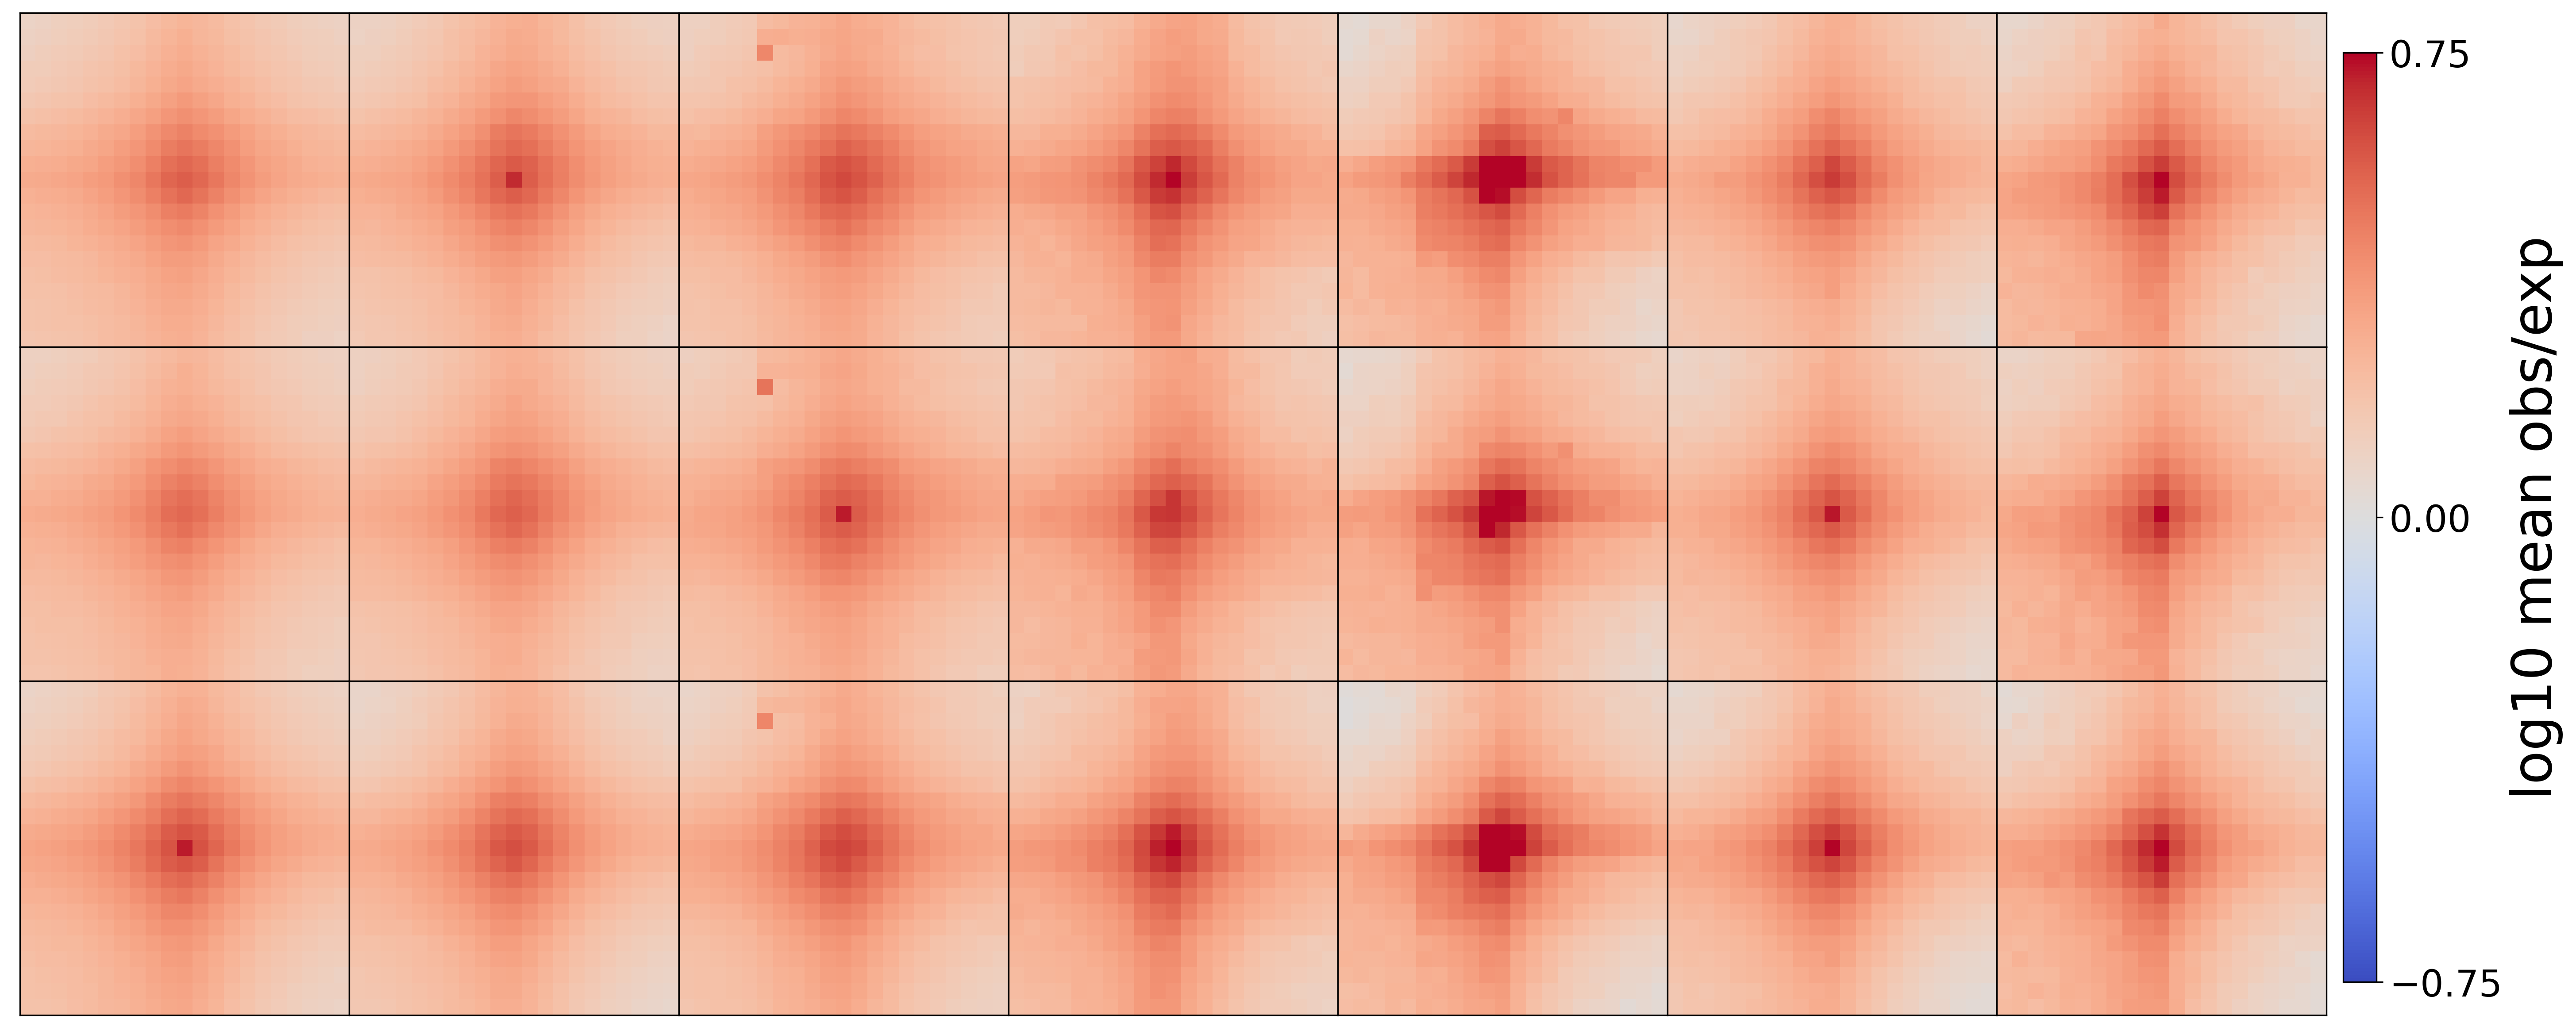

In [100]:
libraries_names=['K562_0000min','K562_0360min','K562_4320min']

# title='Pileup plots of top 10 frequent subsets in the union loop list'
generate_pileup_plots_of_upset_plot(pileup_mtx=output,
                                    row_names=libraries_names,
                                    col_names=dot_subsets_names,
                                    resolution=5000,
                                    flank=50000,
                                    width=25,
                                    height=10,
                                    figure_filename='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_5/pileup_plot_of_union_dot_list_of_Bond_et_al_2023_5kb_old_method.svg')



In [113]:
# create loop strength heatmap
import numpy as np
def quantify_loops(mtx):
    sq_size = mtx.shape[0]
    midpoint = int(np.floor(sq_size/2))
    mid_9pixels_mean = np.nanmean(mtx[midpoint-1:midpoint+2,midpoint-1:midpoint+2])
    neighboring_size = int(np.ceil(0.3*sq_size) // 2 * 2 + 1) # get the closest odd number of 30% sq_size
    upper_left_mean = np.nanmean(mtx[:neighboring_size,:neighboring_size])
    upper_right_mean = np.nanmean(mtx[:neighboring_size, (sq_size-neighboring_size):])
    lower_right_mean = np.nanmean(mtx[(sq_size-neighboring_size):, (sq_size-neighboring_size):])
    return mid_9pixels_mean/np.nanmean(np.array([upper_left_mean,upper_right_mean,lower_right_mean]))
    

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm

def generate_loop_strength_matrix_of_upset_plot_stage_specific(pileup_mtx, row_names, col_names, figure_filename=None, width=35, height=20, vmin=-2, vmax=2):    
    with open(pileup_mtx, 'rb') as f:
        pileup_mtx = pickle.load(f)
    
    loop_strength_matrix=np.zeros((len(row_names),len(col_names)))
    for row in np.arange(len(row_names)):
        for col in np.arange(len(col_names)):
            loop_strength_matrix[row,col]=quantify_loops(pileup_mtx[row,col])
            
    # Compute mean and standard deviation along the desired axis
    mean = np.mean(loop_strength_matrix)
    std = np.std(loop_strength_matrix)

    # Z-score normalization
    loop_strength_matrix_Z = (loop_strength_matrix - mean) / std

    plt.rcParams['figure.figsize'] = [width, height]
    plt.rcParams['figure.dpi'] = 300
    fig, ax = plt.subplots()
    im=ax.imshow(
            loop_strength_matrix_Z,
            cmap='coolwarm',
            vmin=vmin,
            vmax=vmax)

    ax.yaxis.set_ticks([])  # Hide y-axis ticks
    ax.xaxis.set_ticks([])  # Hide x-axis ticks
    
    # Add black grid between cells
    ax.set_xticks(np.arange(len(col_names) + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(len(row_names) + 1) - 0.5, minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=1)
    ax.tick_params(which='minor', bottom=False, left=False)

    cbar_ax = fig.add_axes([0.91, 0.21, 0.01, 0.59])
    cb=fig.colorbar(im, cax=cbar_ax)
    cb.set_ticks([vmin, 0, vmax])  # Only 3 ticks
    cb.ax.tick_params(labelsize=30)
    cb.set_label(label='Z(loop strength)', size=40)
    
    if figure_filename is not None:
        plt.savefig(figure_filename, format='svg', bbox_inches='tight')
        

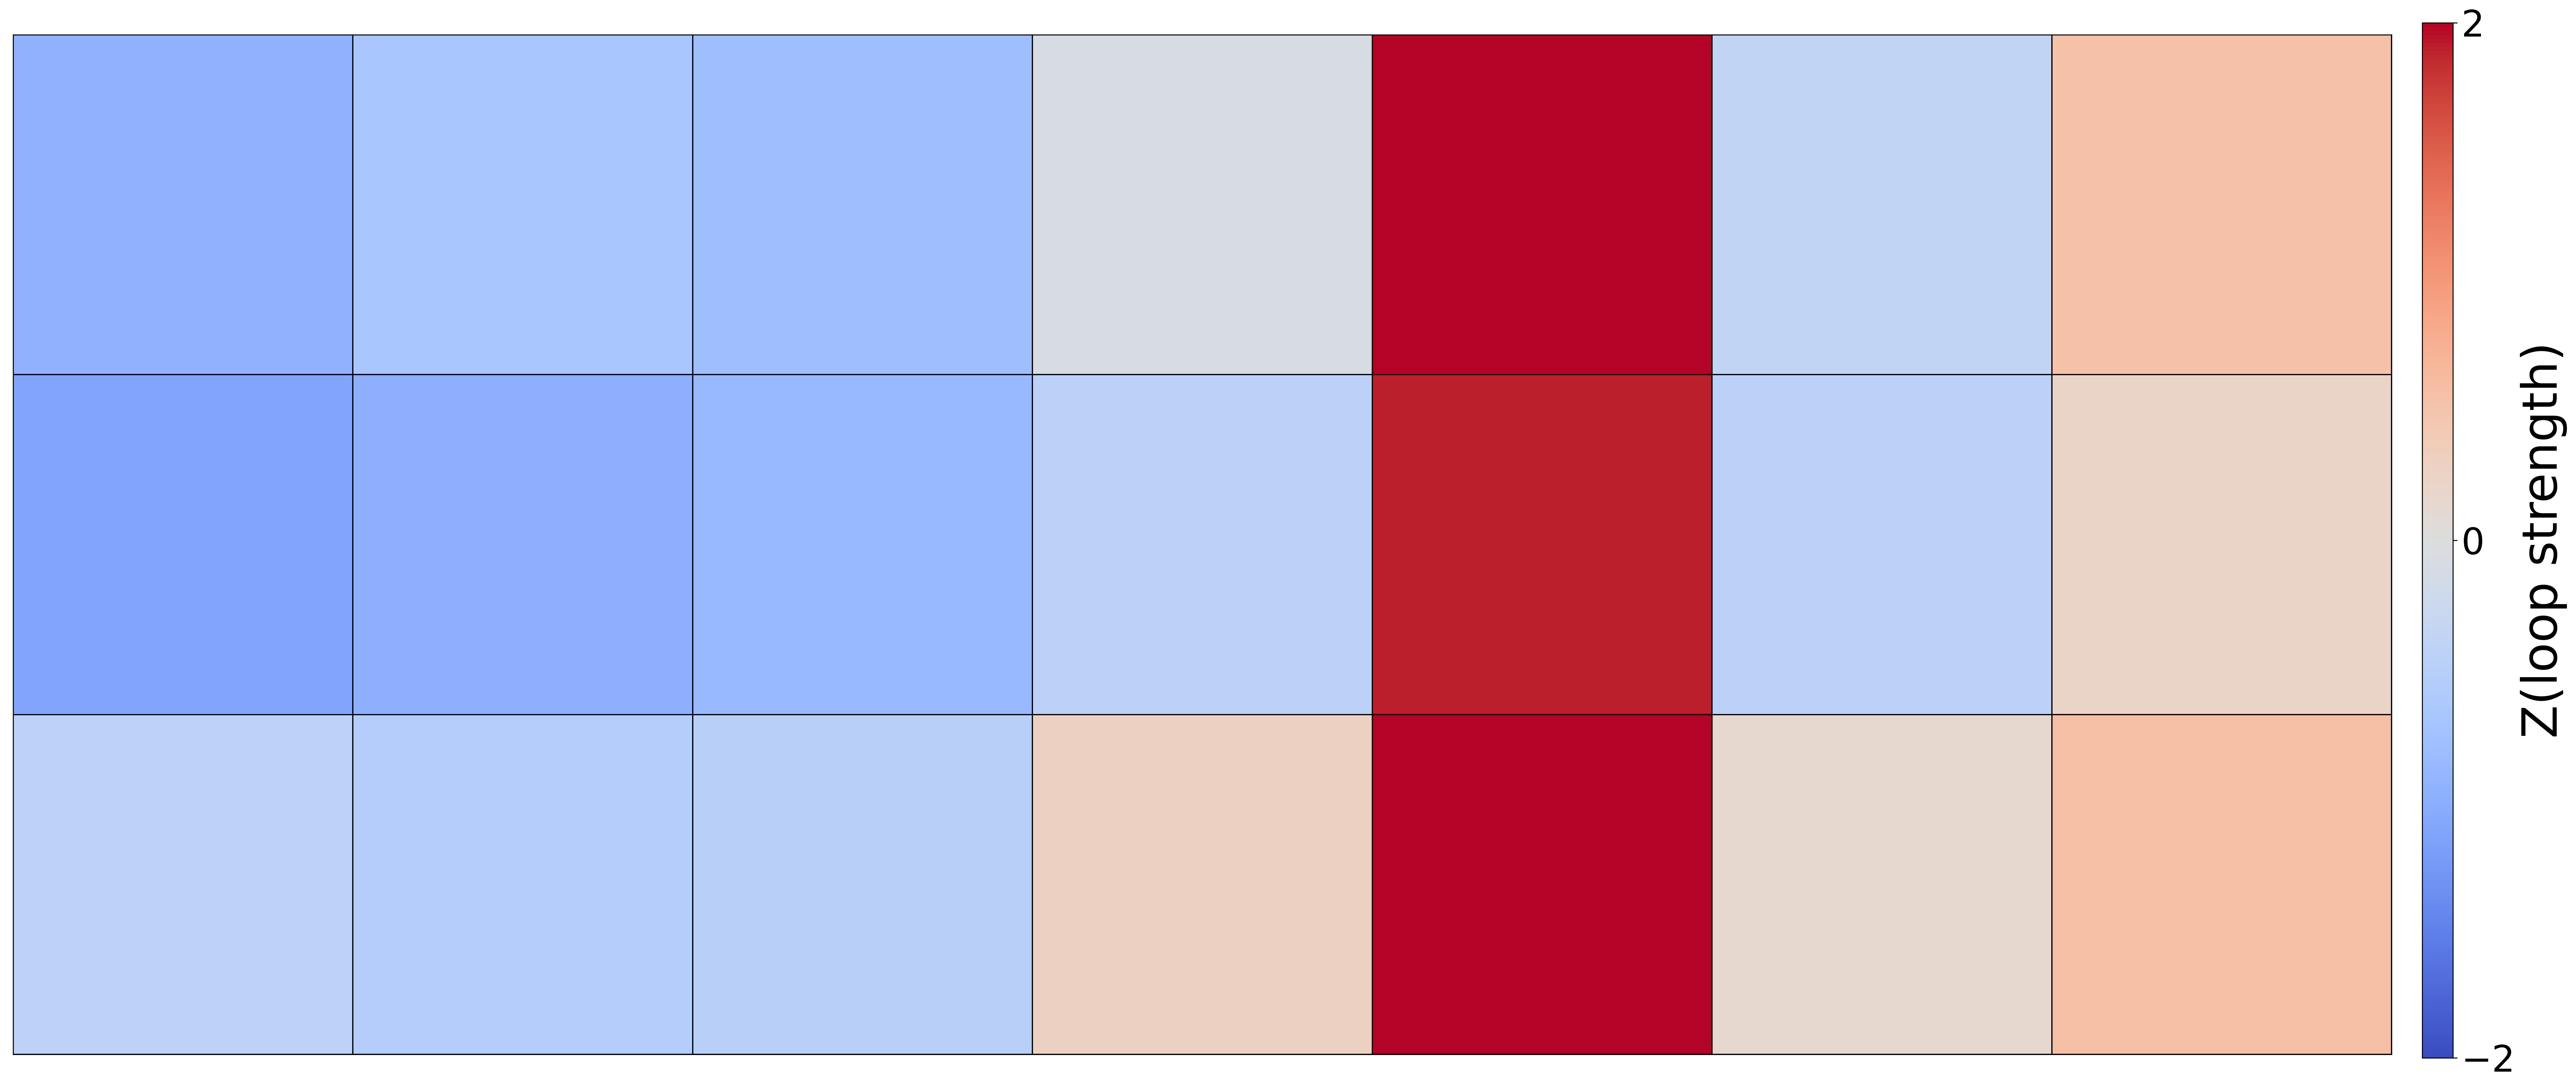

In [114]:
generate_loop_strength_matrix_of_upset_plot_stage_specific(pileup_mtx=output,
                                                           row_names=libraries_names,
                                                           col_names=dot_subsets_names_cli.split(','),
                                                           vmin=-2,
                                                           vmax=2,
                                                           figure_filename='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_5/loop_strength_heatmap_of_pileup_plot_of_union_dot_list_of_Bond_et_al_2023_5kb_old_method.svg'
                                                          )

### Upset plot of all 7 subsets (R kernel) (new method)

In [1]:
# R kernel
library(UpSetR)
library(grid)
library(stringr)

Warning message:
“package ‘UpSetR’ was built under R version 4.0.5”
Warning message:
“package ‘stringr’ was built under R version 4.0.5”


In [2]:
df1=read.table(file = '/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new/results/Bond_et_al_2023_union_loop_list_5kb.tsv', sep = '\t', header = TRUE)
upsetplot_input=table(df1$sample_name)

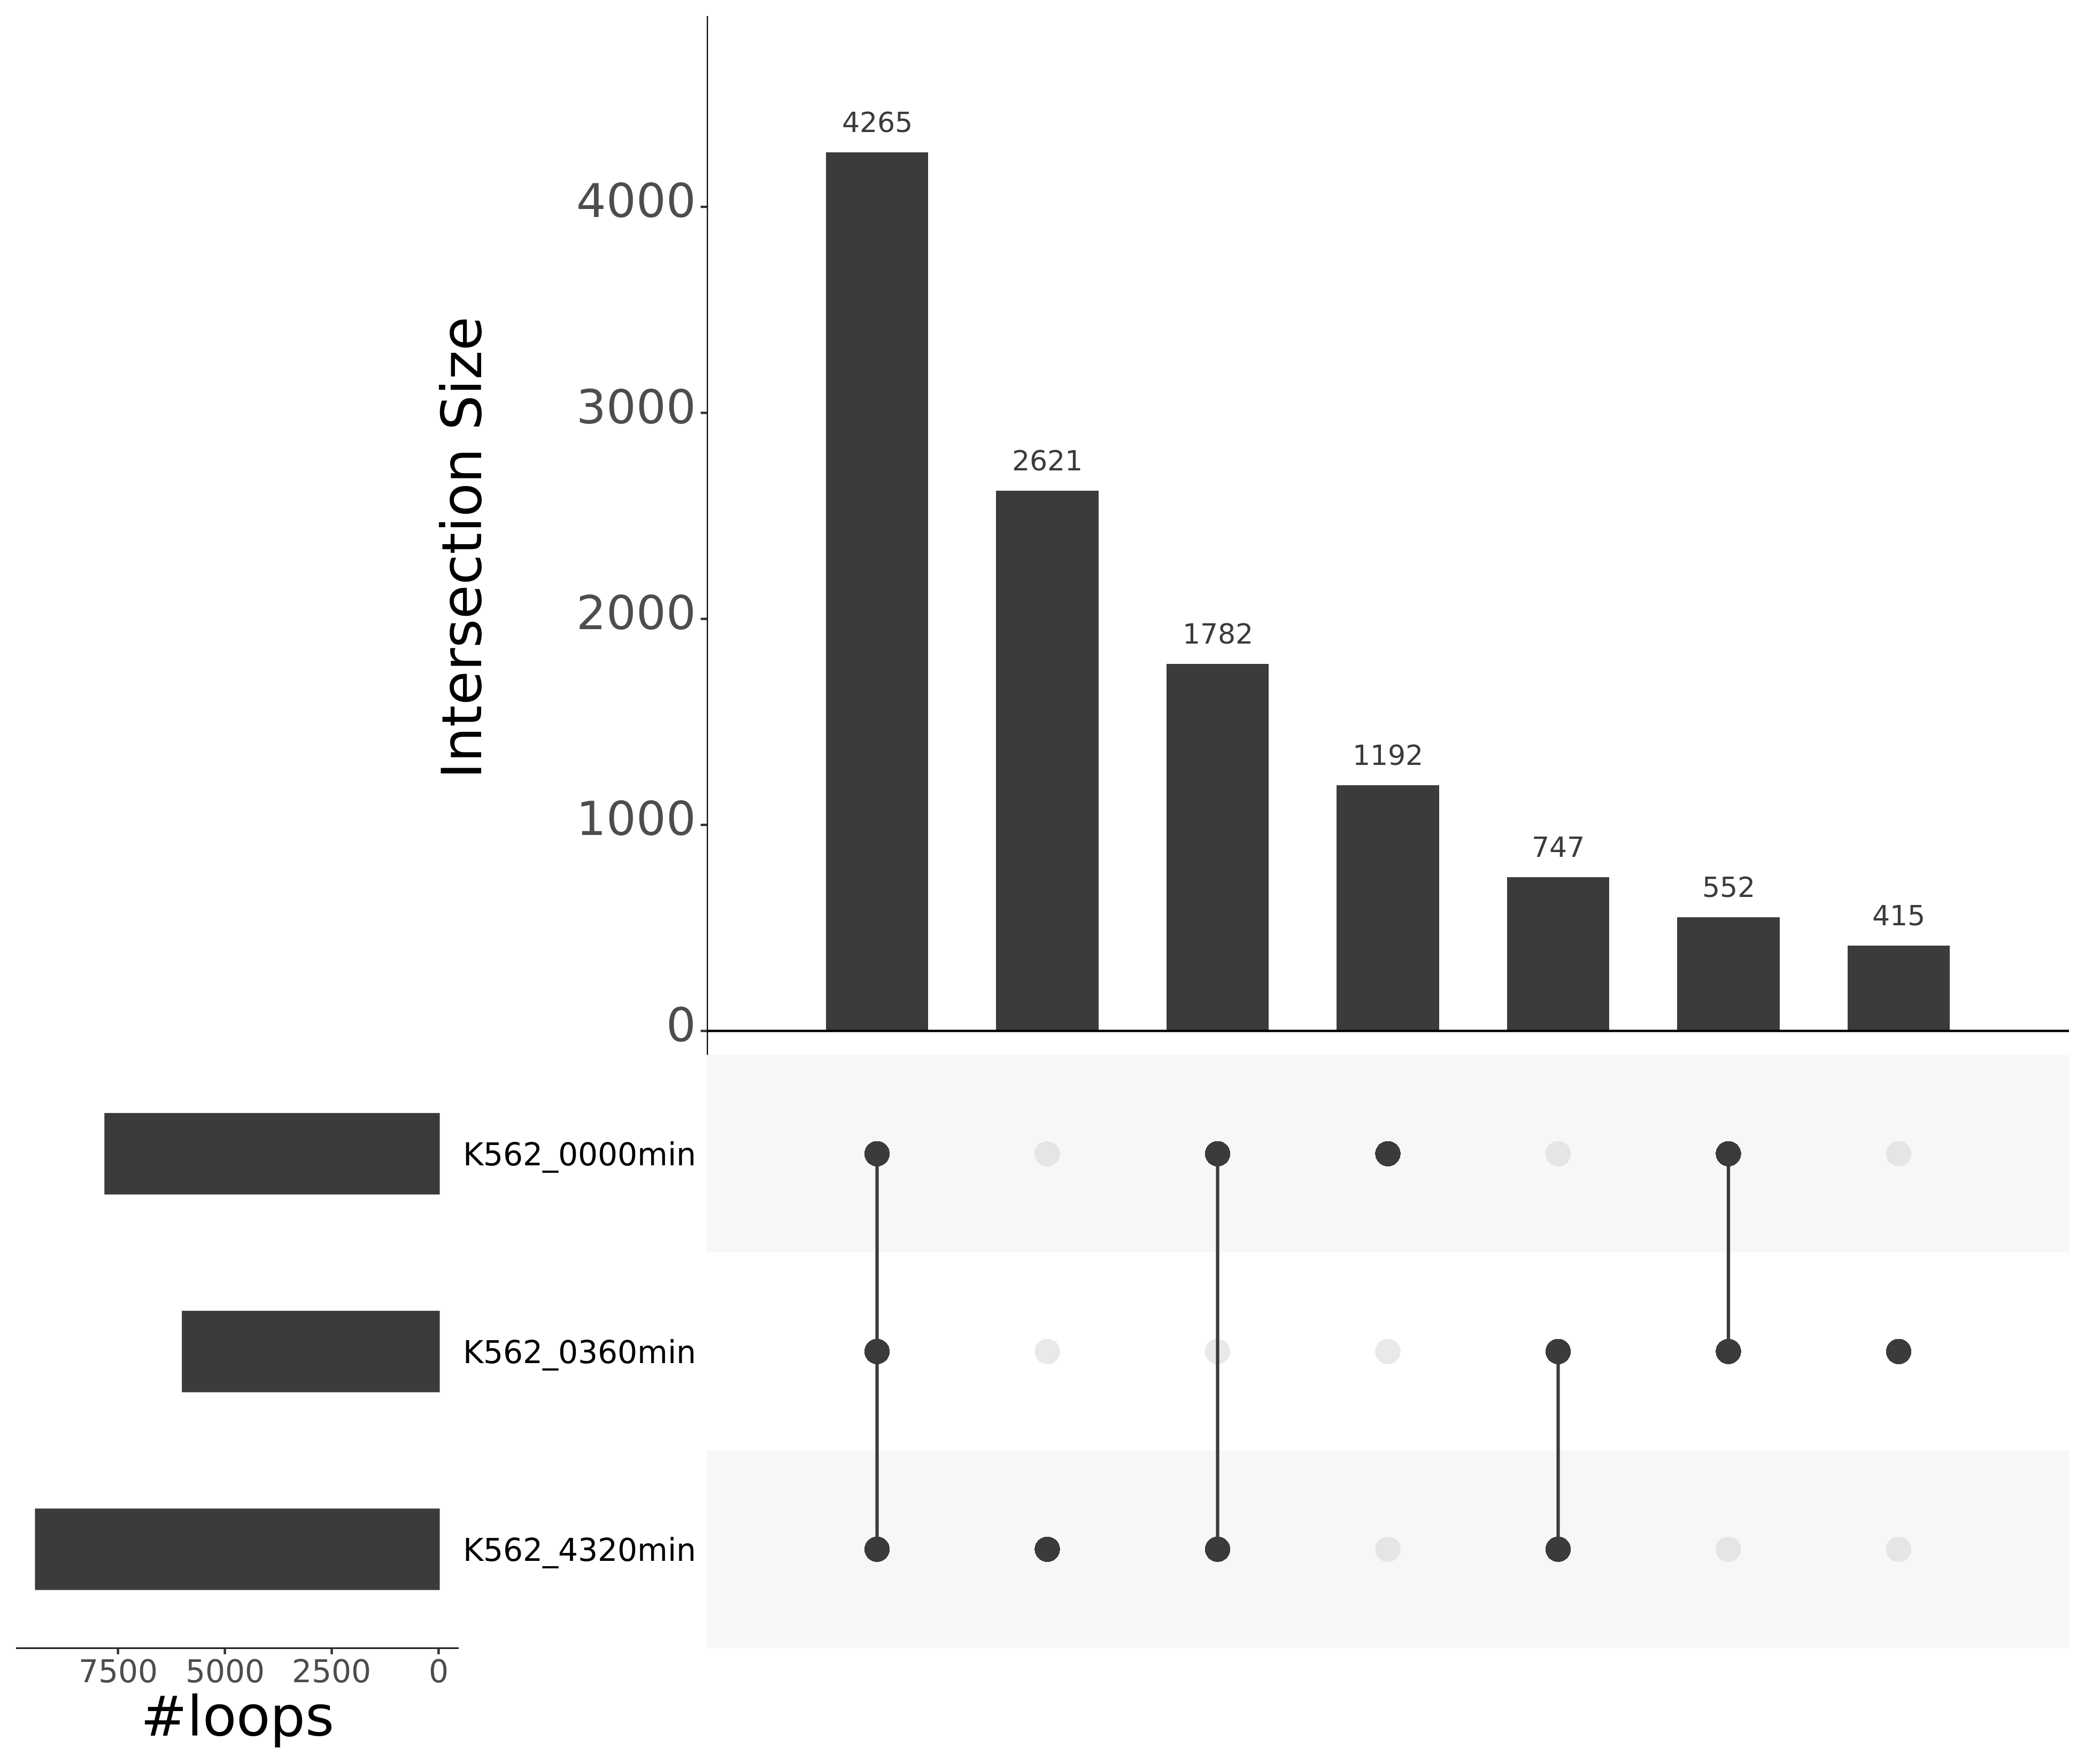

In [3]:
options(repr.plot.width = 13, repr.plot.height = 11, repr.plot.res = 300)
upset(fromExpression(upsetplot_input), 
      nintersects = 7,
      keep.order = T,
      order.by = 'freq',
      text.scale=c(3, 3, 3, 2, 2, 2),
      point.size=5,
      mb.ratio = c(0.6, 0.4),
      sets = c('K562_4320min',
               'K562_0360min',
               'K562_0000min'),
      sets.x.label = "#loops"#x axis small plot
      )
# grid.text("Upset plots of the union loop list called\nfrom each individual libraries (5kb resolution)", x = 0.7, y = 0.97, gp = gpar(fontsize = 15))


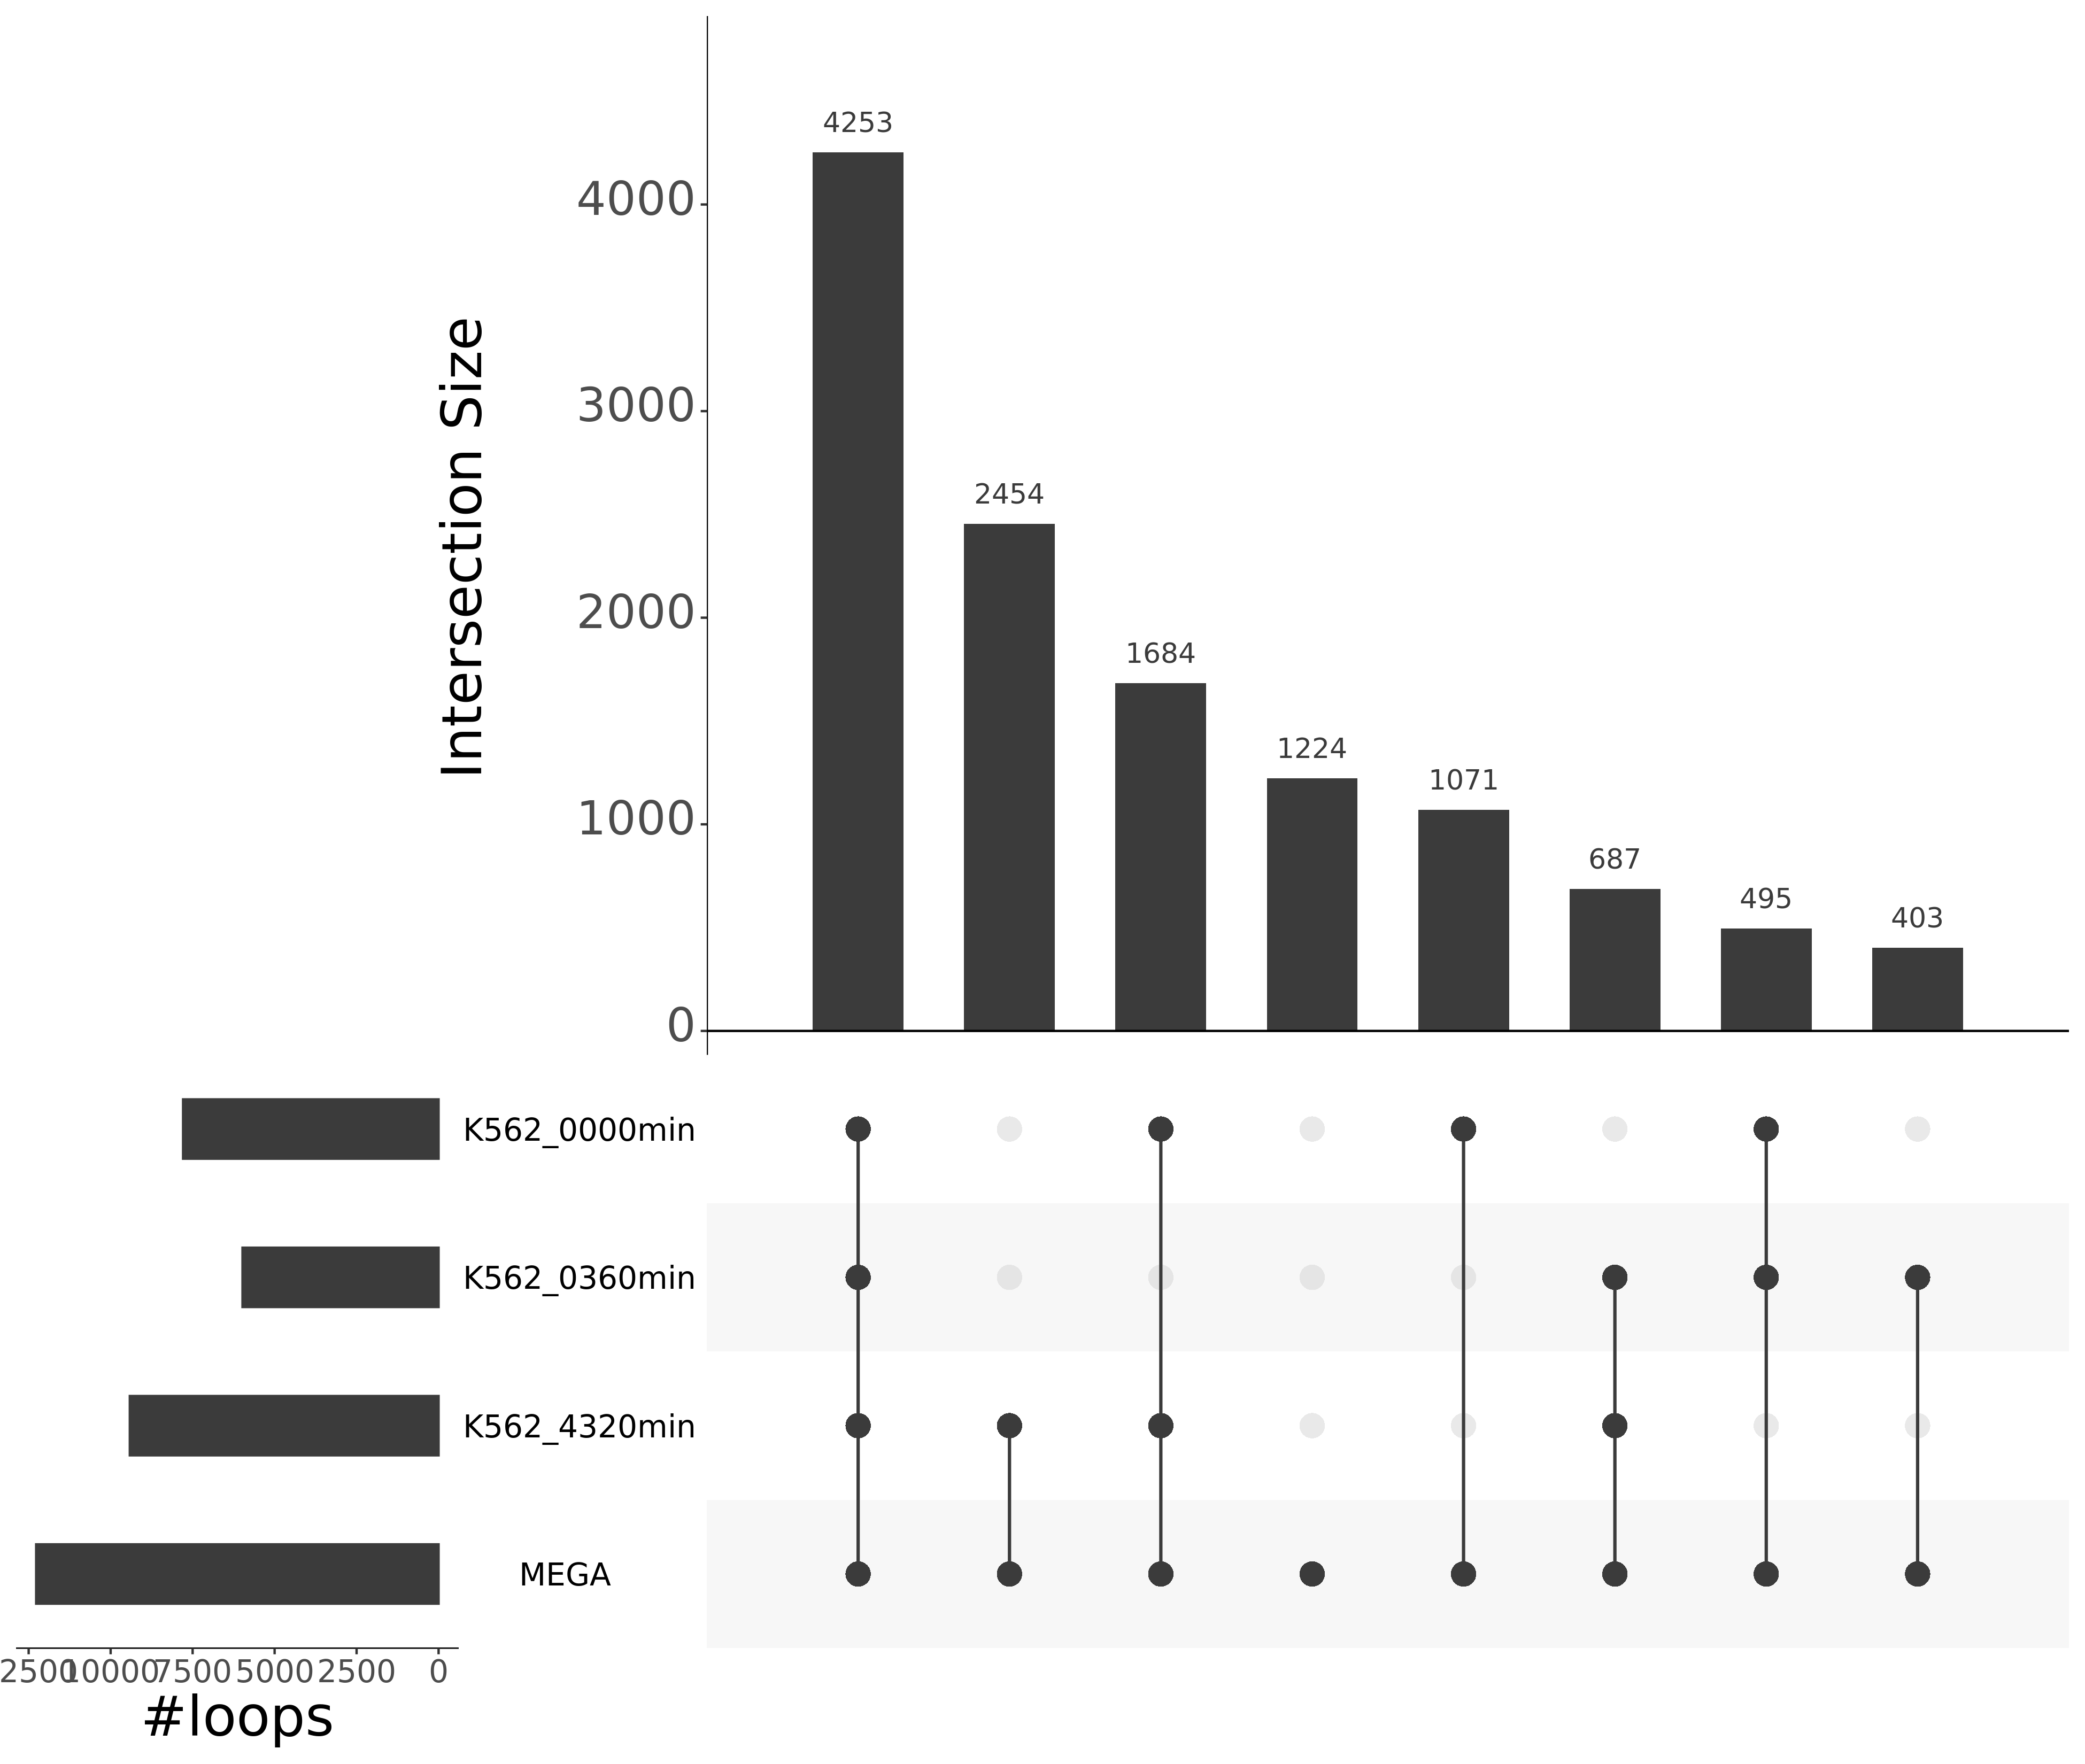

In [6]:
options(repr.plot.width = 13, repr.plot.height = 11, repr.plot.res = 300)
upset(fromExpression(upsetplot_input), 
      nintersects = 8,
      keep.order = T,
      order.by = 'freq',
      text.scale=c(3, 3, 3, 2, 2, 2),
      point.size=5,
      mb.ratio = c(0.6, 0.4),
      sets = c('MEGA',
               'K562_4320min',
               'K562_0360min',
               'K562_0000min'),
      sets.x.label = "#loops"#x axis small plot
      )
# grid.text("Upset plots of the union loop list called\nfrom each individual libraries (5kb resolution)", x = 0.7, y = 0.97, gp = gpar(fontsize = 15))


In [4]:
# MEGA-specific
sum(df1$sample_name == 'MEGA')

[1] 1224

In [5]:
# Total number of loops called from three time points
nrow(df1) - sum(df1$sample_name == 'MEGA')

[1] 11574

In [6]:
# How many loops from each library (note: These numbers correspond to left bars)
for (cond in c('K562_0000min',
               'K562_0360min',
               'K562_4320min',
               'MEGA')) {
  print(paste(c(paste0(c(cond, ": "), collapse=''), sum(str_detect(df1$sample_name, cond))), collapse=''))
}


[1] "K562_0000min: 7791"
[1] "K562_0360min: 5979"
[1] "K562_4320min: 9415"
[1] "MEGA: 12271"


### R kernel (local laptop)

In [ ]:
#  Bond et al 2023 (5kb, new method)

library(ComplexHeatmap)

df1 <- read.table(file = 'Bond_et_al_2023_union_loop_list_5kb.tsv', sep = '\t', header = TRUE)

# Create the list with the desired order
lt <- setNames(list(
  K562_0000min = which(grepl("K562_0000min", df1$sample_name)),
  K562_0360min = which(grepl("K562_0360min", df1$sample_name)),
  K562_4320min = which(grepl("K562_4320min", df1$sample_name))
), c("0 hour", "6 hour", "72 hour")
)

# Create combination matrix
m <- make_comb_mat(lt)

# Set the order of sets (used in plotting, not subsetting)
set_name_order <- c("0 hour", "6 hour", "72 hour")

# Get the sizes of all combinations
sizes <- comb_size(m)

# Get the indices of the top n most frequent intersections
top_n <- 7
top_n_indices <- order(sizes, decreasing = TRUE)[1:top_n]

# Subset the combination matrix to only those top n
m_top_n <- m[top_n_indices]


# Save as PDF
# Save pdf, open pdf in illustrator, it will become svg automatically.
# I upload this figure from my laptop to 
# /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_5
pdf("upset_plot_of_union_dot_list_of_Bond_et_al_2023_5kb_new_method.pdf", width = 5, height = 3)

# Plot only those
UpSet(
  m_top_n,
  comb_order = seq_along(top_n_indices),  # order is already limited
  set_order = set_name_order,
  top_annotation = upset_top_annotation(m_top_n, 
                                        add_numbers = TRUE, 
                                        numbers_rot = 0, 
                                        numbers_gp = gpar(fontsize = 8)
  ),
  right_annotation = upset_right_annotation(
    m_top_n,
    add_numbers = TRUE,
    numbers_gp = gpar(fontsize = 8),
    gp = gpar(fill = "#A9A9A9"),
    annotation_name_side = "top",
    axis_param = list(side = "top")
  ),
  column_names_rot = 0,
  pt_size = unit(5, "mm")
)

dev.off()

In [ ]:
sessionInfo()
# R version 4.1.1 (2021-08-10)
# Platform: x86_64-apple-darwin17.0 (64-bit)
# Running under: macOS Monterey 12.7.6
# 
# Matrix products: default
# LAPACK: /Library/Frameworks/R.framework/Versions/4.1/Resources/lib/libRlapack.dylib
# 
# locale:
#   [1] en_US.UTF-8/en_US.UTF-8/en_US.UTF-8/C/en_US.UTF-8/en_US.UTF-8
# 
# attached base packages:
#   [1] grid      stats     graphics  grDevices utils     datasets  methods   base     
# 
# other attached packages:
#   [1] ComplexHeatmap_2.10.0
# 
# loaded via a namespace (and not attached):
#   [1] circlize_0.4.16     matrixStats_1.5.0   codetools_0.2-20    IRanges_2.28.0      png_0.1-8          
# [6] digest_0.6.37       foreach_1.5.2       crayon_1.5.3        stats4_4.1.1        GlobalOptions_0.1.2
# [11] doParallel_1.0.17   S4Vectors_0.32.4    GetoptLong_1.0.5    RColorBrewer_1.1-3  rjson_0.2.23       
# [16] iterators_1.0.14    tools_4.1.1         parallel_4.1.1      compiler_4.1.1      clue_0.3-65        
# [21] colorspace_2.1-1    BiocGenerics_0.40.0 cluster_2.1.8.1     shape_1.4.6.1      



### Pileup plot of all 7 subsets corresponding to above upset plots (new method)

In [135]:
import itertools
import numpy as np
import pandas as pd

def all_combinations(input_list):
    all_combos = []
    for r in range(1, len(input_list) + 1):
        combos = list(itertools.combinations(input_list, r))
        all_combos.extend(combos)
    return all_combos


input_list = np.sort(['K562_0000min','K562_0360min','K562_4320min','MEGA'])
combinations = all_combinations(input_list)
combinations_list=[]
for combo in combinations:
    combinations_list.append('&'.join(combo))


In [136]:
dots_file='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new/results/Bond_et_al_2023_union_loop_list_5kb.tsv'
dots=pd.read_csv(dots_file, sep='\t')

dots_exclude_libraries=['MEGA'] # remove 'MEGA' labels
dots['sample_name']=dots['sample_name'].apply(lambda x: '&'.join(np.sort(list(set(x.split('&')) - set(dots_exclude_libraries)))))
dots=dots.loc[dots['sample_name'] != ''].reset_index(drop=True) # remove rows (with )

# dots.to_csv('/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new/Bond_et_al_2023_union_loop_list_5kb_without_MEGA.tsv', sep='\t', index=False, header=True)


In [137]:
dot_subsets=dots.loc[dots.sample_name.isin(combinations_list)].copy()
n=7
num_of_available_dot_subsets=len(dot_subsets.sample_name.value_counts())
assert n <= num_of_available_dot_subsets, f"n should be less than or equal to {num_of_available_dot_subsets}"

dot_subsets_names=list(dot_subsets.sample_name.value_counts()[range(n)].index) # top n frequent subsets of loops

In [138]:
dots_file='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new/Bond_et_al_2023_union_loop_list_5kb_without_MEGA.tsv' # without MEGA labels
cooler_meta='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/cooler_paths_of_Bond_et_al_2023.tsv'
dot_subsets_names_cli=(','.join(dot_subsets_names)).replace("&", "\&") # In a Unix-like shell, escape the & with a backslash (\) 
libraries_names='K562_0000min,K562_0360min,K562_4320min'

resolution=5000
flank=50000
output='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new/pileup_matrices_of_all_7_subsets_of_union_dot_list_5kb_resolution_50kb_flank_without_MEGA.pickle'


# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 8 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/generate_a_matrix_of_pileup_plots_for_its_corresponding_upset_plot.py $dots_file $cooler_meta $libraries_names $dot_subsets_names_cli $resolution $flank $output"


In [139]:
import numpy as np
def quantify_loops(mtx):
    sq_size = mtx.shape[0]
    midpoint = int(np.floor(sq_size/2))
    mid_9pixels_mean = np.nanmean(mtx[midpoint-1:midpoint+2,midpoint-1:midpoint+2])
    neighboring_size = int(np.ceil(0.3*sq_size) // 2 * 2 + 1) # get the closest odd number of 30% sq_size
    upper_left_mean = np.nanmean(mtx[:neighboring_size,:neighboring_size])
    upper_right_mean = np.nanmean(mtx[:neighboring_size, (sq_size-neighboring_size):])
    lower_right_mean = np.nanmean(mtx[(sq_size-neighboring_size):, (sq_size-neighboring_size):])
    return mid_9pixels_mean/np.nanmean(np.array([upper_left_mean,upper_right_mean,lower_right_mean]))
    

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


def generate_pileup_plots_of_upset_plot(pileup_mtx, row_names, col_names, resolution, flank, title='', figure_filename=None, width=35, height=20):    
    with open(pileup_mtx, 'rb') as f:
        pileup_mtx = pickle.load(f)
        
    plt.rcParams['figure.figsize'] = [width, height]
    plt.rcParams['figure.dpi'] = 300
    fig, axes = plt.subplots(nrows=len(row_names), ncols=len(col_names), squeeze=False)
    fig.subplots_adjust(right=0.82, wspace=0, hspace=0)
    for row in np.arange(len(row_names)):
        for col in np.arange(len(col_names)):
            log10_mtx=np.log10(pileup_mtx[row,col])
            im=axes[row,col].imshow(
                log10_mtx,
                vmax = 0.75,
                vmin = -0.75,
                cmap='coolwarm',
                aspect='auto')
#             axes[row,col].tick_params(axis='both', labelsize=15)
#             if row == 0:
#                 axes[row,col].set_title(col_names[col],fontsize=17,y=1.02)
#             if col == 0:
#                 axes[row,col].set_ylabel(row_names[row],fontsize=20)
#             axes[row,col].text(12, 3, f"{quantify_loops(pileup_mtx[row,col]):.2f}", fontsize=20)

            # Hide all ticks by default
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])
            
#             ticks_pixels = np.linspace(0, flank*2//resolution,5)
#             ticks_kbp = ((ticks_pixels-ticks_pixels[-1]/2)*resolution//1000).astype(int)
#             axes[row,col].set_xticks(ticks_pixels) 
#             axes[row,col].set_xticklabels(ticks_kbp)
#             axes[row,col].set_yticks(ticks_pixels) 
#             axes[row,col].set_yticklabels(ticks_kbp)
#             axes[row,col].xaxis.set_major_locator(ticker.NullLocator())
#             axes[row,col].yaxis.set_major_locator(ticker.NullLocator())

#     fig.text(0.48, 0.08, 'relative position, kbp', ha='center', fontsize=30)
#     fig.text(0.08, 0.5, 'relative position, kbp', va='center', rotation='vertical', fontsize=30)
#     fig.suptitle(f'{title} (flank={int(flank/1000)}kbp, resolution={resolution}bp)',fontsize=27, y=0.95)
    fig.subplots_adjust(right=0.82)
    
    cbar_ax = fig.add_axes([0.825, 0.15, 0.01, 0.7])
    cb = fig.colorbar(im, cax=cbar_ax)
    cb.set_ticks([-0.75, 0, 0.75])  # Only 3 ticks
    cb.ax.tick_params(labelsize=20)
    cb.set_label(label='log10 mean obs/exp', size=30)
    
    if figure_filename is not None:
        plt.savefig(figure_filename, format='svg', bbox_inches='tight')


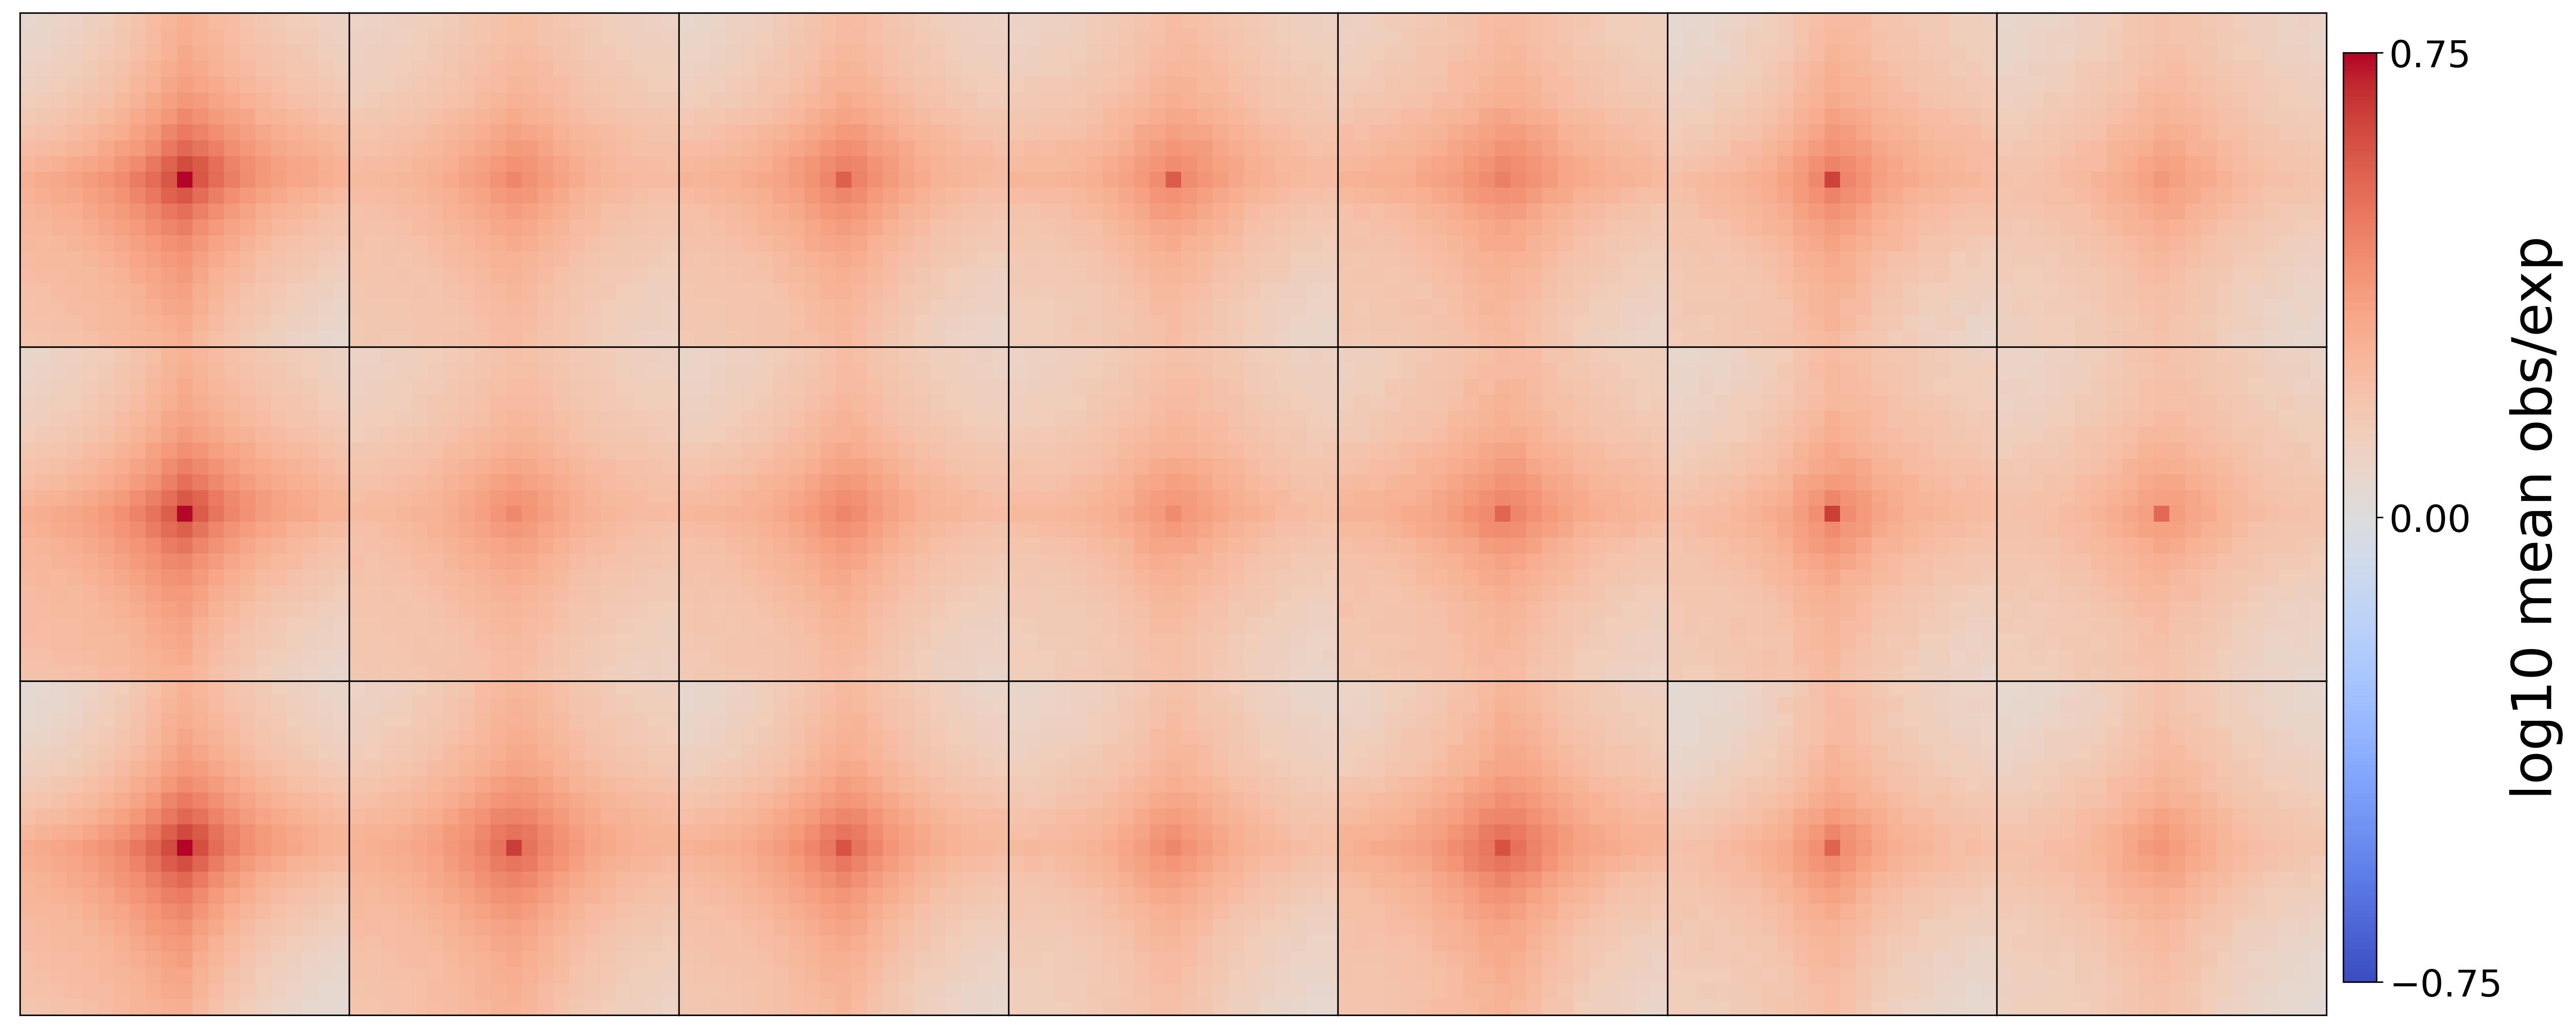

In [140]:
libraries_names=['K562_0000min','K562_0360min','K562_4320min']

# title='Pileup plots of top 10 frequent subsets in the union loop list'
generate_pileup_plots_of_upset_plot(pileup_mtx=output,
                                    row_names=libraries_names,
                                    col_names=dot_subsets_names,
                                    resolution=5000,
                                    flank=50000,
                                    width=25,
                                    height=10,
                                    figure_filename='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_5/pileup_plot_of_union_dot_list_of_Bond_et_al_2023_5kb_new_method.svg')



In [141]:
# create loop strength heatmap
import numpy as np
def quantify_loops(mtx):
    sq_size = mtx.shape[0]
    midpoint = int(np.floor(sq_size/2))
    mid_9pixels_mean = np.nanmean(mtx[midpoint-1:midpoint+2,midpoint-1:midpoint+2])
    neighboring_size = int(np.ceil(0.3*sq_size) // 2 * 2 + 1) # get the closest odd number of 30% sq_size
    upper_left_mean = np.nanmean(mtx[:neighboring_size,:neighboring_size])
    upper_right_mean = np.nanmean(mtx[:neighboring_size, (sq_size-neighboring_size):])
    lower_right_mean = np.nanmean(mtx[(sq_size-neighboring_size):, (sq_size-neighboring_size):])
    return mid_9pixels_mean/np.nanmean(np.array([upper_left_mean,upper_right_mean,lower_right_mean]))
    

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm

def generate_loop_strength_matrix_of_upset_plot_stage_specific(pileup_mtx, row_names, col_names, figure_filename=None, width=35, height=20, vmin=-2, vmax=2):    
    with open(pileup_mtx, 'rb') as f:
        pileup_mtx = pickle.load(f)
    
    loop_strength_matrix=np.zeros((len(row_names),len(col_names)))
    for row in np.arange(len(row_names)):
        for col in np.arange(len(col_names)):
            loop_strength_matrix[row,col]=quantify_loops(pileup_mtx[row,col])
            
    # Compute mean and standard deviation along the desired axis
    mean = np.mean(loop_strength_matrix)
    std = np.std(loop_strength_matrix)

    # Z-score normalization
    loop_strength_matrix_Z = (loop_strength_matrix - mean) / std

    plt.rcParams['figure.figsize'] = [width, height]
    plt.rcParams['figure.dpi'] = 300
    fig, ax = plt.subplots()
    im=ax.imshow(
            loop_strength_matrix_Z,
            cmap='coolwarm',
            vmin=vmin,
            vmax=vmax)

    ax.yaxis.set_ticks([])  # Hide y-axis ticks
    ax.xaxis.set_ticks([])  # Hide x-axis ticks
    
    # Add black grid between cells
    ax.set_xticks(np.arange(len(col_names) + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(len(row_names) + 1) - 0.5, minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=1)
    ax.tick_params(which='minor', bottom=False, left=False)

    cbar_ax = fig.add_axes([0.91, 0.21, 0.01, 0.59])
    cb=fig.colorbar(im, cax=cbar_ax)
    cb.set_ticks([vmin, 0, vmax])  # Only 3 ticks
    cb.ax.tick_params(labelsize=30)
    cb.set_label(label='Z(loop strength)', size=40)
    
    if figure_filename is not None:
        plt.savefig(figure_filename, format='svg', bbox_inches='tight')
        

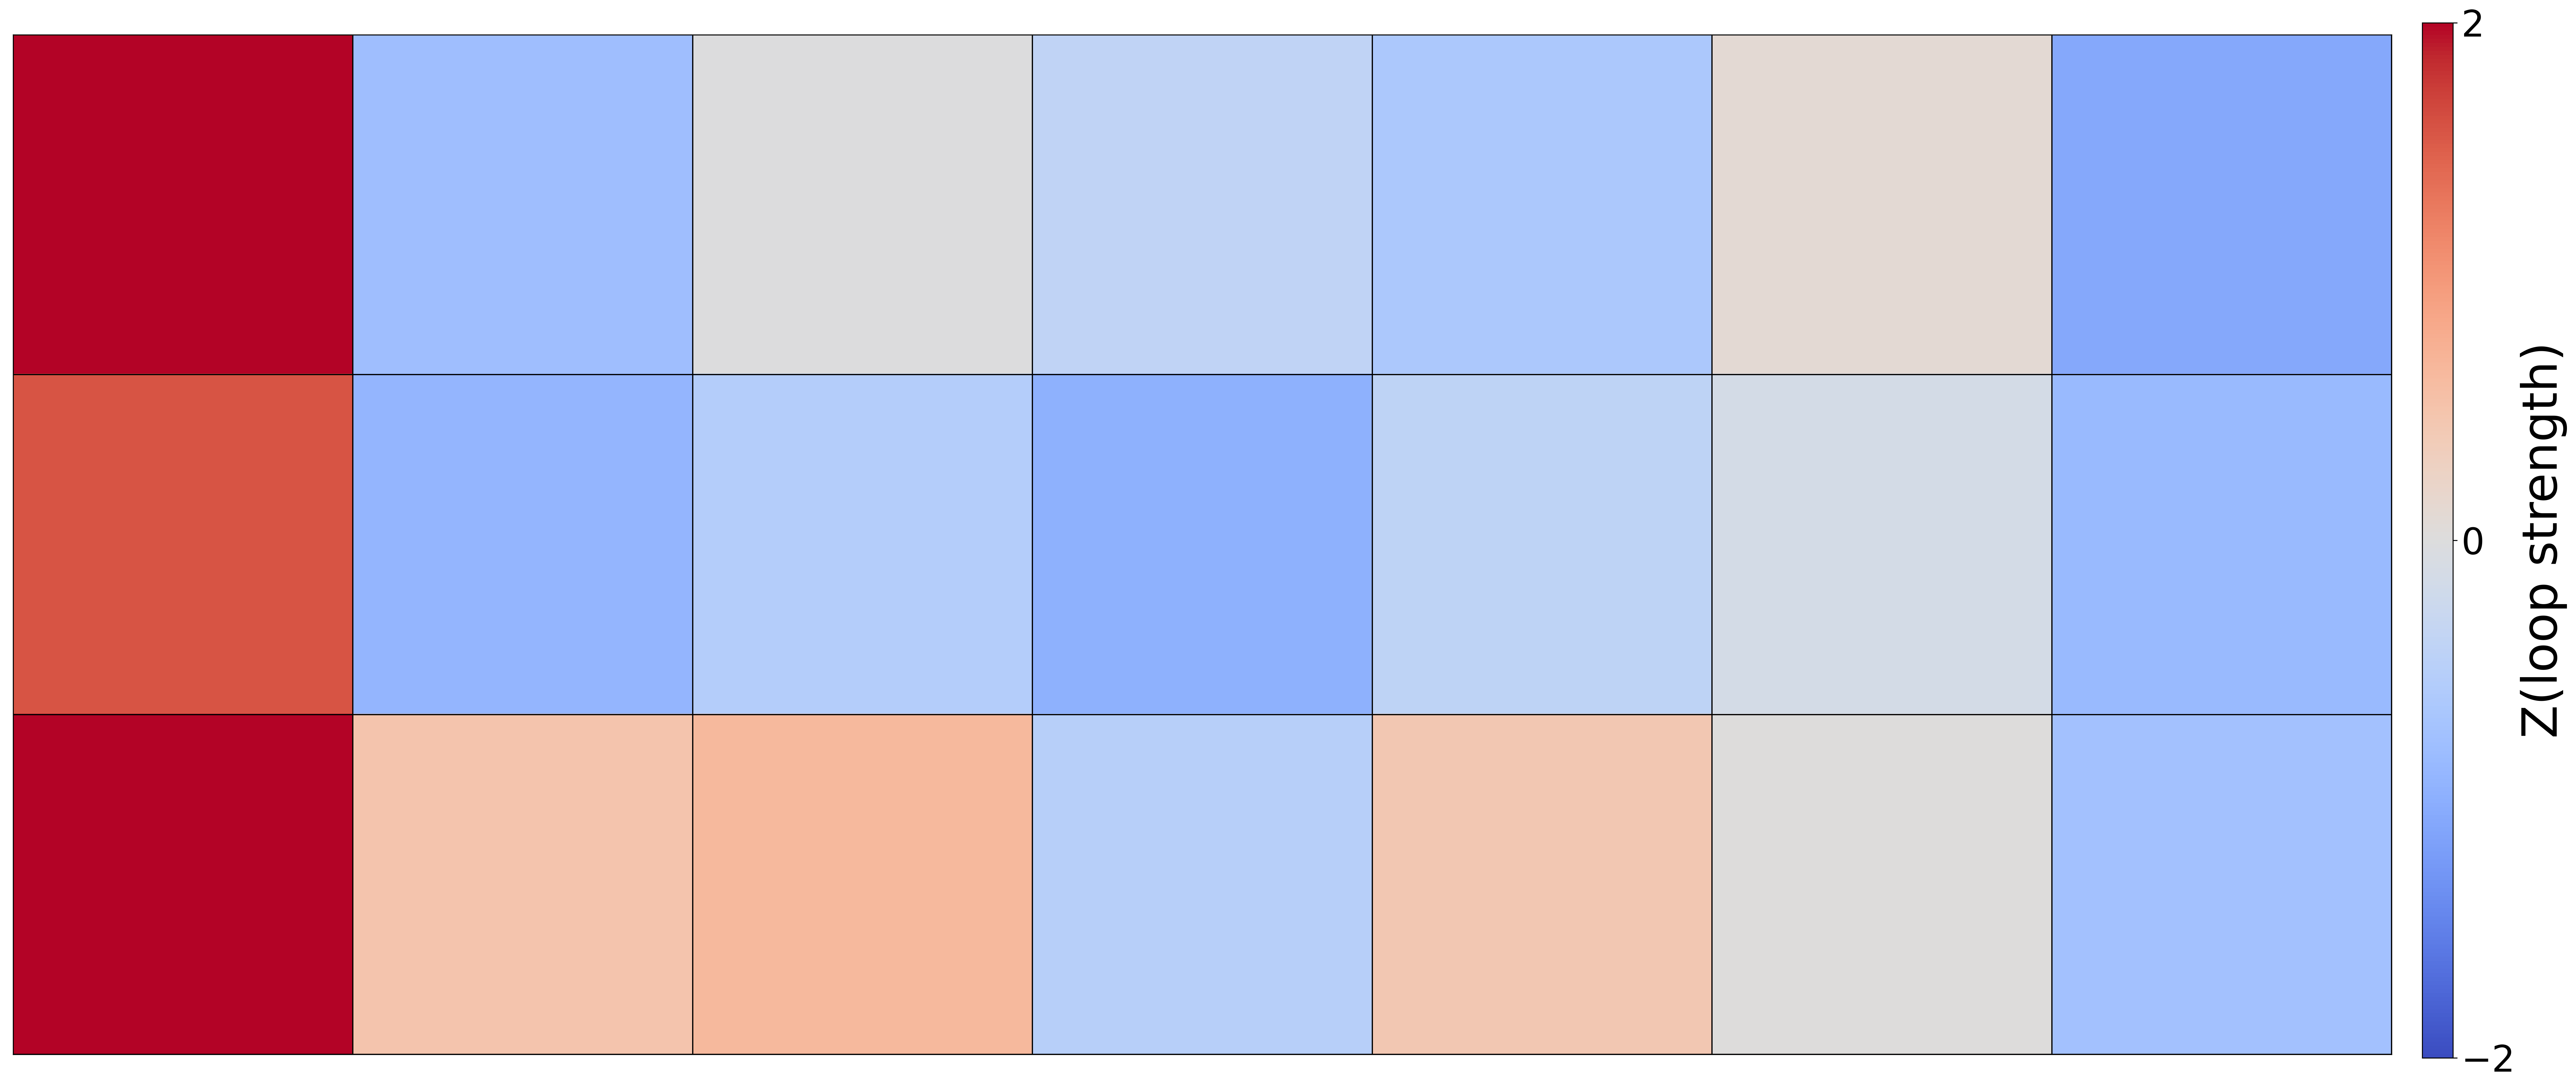

In [142]:
generate_loop_strength_matrix_of_upset_plot_stage_specific(pileup_mtx=output,
                                                           row_names=libraries_names,
                                                           col_names=dot_subsets_names_cli.split(','),
                                                           vmin=-2,
                                                           vmax=2,
                                                           figure_filename='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_5/loop_strength_heatmap_of_pileup_plot_of_union_dot_list_of_Bond_et_al_2023_5kb_new_method.svg'
                                                           )

### Stackup plot of lost and gained loops from 0h to 72h (old method)
Only select the row of each loop in its pileup plot and stack them up

In [1]:
import numpy as np
import pandas as pd

In [2]:
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/'
dots_file=dots_dir+'union_dot_list_of_Bond_et_al_2023_5kb_old_method.txt'
dots=pd.read_csv(dots_file, sep='\t')

# only 0h, 72h
dots_exclude_libraries=['K562_0360min','MEGA'] # remove 'MEGA', 'K562_0360min' labels
dots['sample_name']=dots['sample_name'].apply(lambda x: '&'.join(np.sort(list(set(x.split('&')) - set(dots_exclude_libraries)))))
dots=dots.loc[dots['sample_name'] != ''].reset_index(drop=True) # remove rows (with )

# lost (0h specific)
lost_dots=dots.loc[dots.sample_name == 'K562_0000min'].copy()
# gained (72h specific)
gained_dots=dots.loc[dots.sample_name == 'K562_4320min'].copy()

# lost_dots.to_csv(dots_dir+'lost_loops_from_0h_to_72h_of_Bond_et_al_2023_5kb_old_method.txt', sep='\t', index=False, header=True)
# gained_dots.to_csv(dots_dir+'gained_loops_from_0h_to_72h_of_Bond_et_al_2023_5kb_old_method.txt', sep='\t', index=False, header=True)


In [1]:
# lost at 0h cooler
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/'
dots_file=dots_dir+'lost_loops_from_0h_to_72h_of_Bond_et_al_2023_5kb_old_method.txt'
# 0h cooler
cooler_file='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/coolers/HIC_K562_0000min_biorep1_to_4__hg38.hg38.mapq_30.1000.mcool'
resolution=5000
flank=50000
output=dots_dir+'stackup_matrix_of_lost_loops_from_0h_to_72h_at_0h_cooler_5kb_resolution_50kb_flank.pickle'

# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 4 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/generate_a_stackup_matrix_of_center_rows_of_pileup_plots_of_loops.py $dots_file $cooler_file $resolution $flank $output"


Job <787954> is submitted to queue <long>.


In [2]:
# lost at 72h cooler
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/'
dots_file=dots_dir+'lost_loops_from_0h_to_72h_of_Bond_et_al_2023_5kb_old_method.txt'
# 72h cooler
cooler_file='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/coolers/HIC_K562_4320min_biorep1_to_4__hg38.hg38.mapq_30.1000.mcool'
resolution=5000
flank=50000
output=dots_dir+'stackup_matrix_of_lost_loops_from_0h_to_72h_at_72h_cooler_5kb_resolution_50kb_flank.pickle'

# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 4 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/generate_a_stackup_matrix_of_center_rows_of_pileup_plots_of_loops.py $dots_file $cooler_file $resolution $flank $output"


Job <787955> is submitted to queue <long>.


In [3]:
# gained at 0h cooler
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/'
dots_file=dots_dir+'gained_loops_from_0h_to_72h_of_Bond_et_al_2023_5kb_old_method.txt'
# 0h cooler
cooler_file='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/coolers/HIC_K562_0000min_biorep1_to_4__hg38.hg38.mapq_30.1000.mcool'
resolution=5000
flank=50000
output=dots_dir+'stackup_matrix_of_gained_loops_from_0h_to_72h_at_0h_cooler_5kb_resolution_50kb_flank.pickle'

# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 4 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/generate_a_stackup_matrix_of_center_rows_of_pileup_plots_of_loops.py $dots_file $cooler_file $resolution $flank $output"


Job <787956> is submitted to queue <long>.


In [4]:
# gained at 72h cooler
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/'
dots_file=dots_dir+'gained_loops_from_0h_to_72h_of_Bond_et_al_2023_5kb_old_method.txt'
# 72h cooler
cooler_file='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/coolers/HIC_K562_4320min_biorep1_to_4__hg38.hg38.mapq_30.1000.mcool'
resolution=5000
flank=50000
output=dots_dir+'stackup_matrix_of_gained_loops_from_0h_to_72h_at_72h_cooler_5kb_resolution_50kb_flank.pickle'

# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 4 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/generate_a_stackup_matrix_of_center_rows_of_pileup_plots_of_loops.py $dots_file $cooler_file $resolution $flank $output"


Job <787957> is submitted to queue <long>.


In [12]:
import pickle
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

def create_two_stackup_plots_side_by_side(stackup_left, stackup_right, 
                                          stackup_left_title='', stackup_right_title='', 
                                          sorted_by='left', resolution=5000, 
                                          flank=50000, vmax=0.75, vmin=-0.75,
                                          output_svg_filename_of_stackup=None):
    # Load data
    with open(stackup_left, 'rb') as f:
        stackup_mtx_left = pickle.load(f)
    with open(stackup_right, 'rb') as f:
        stackup_mtx_right = pickle.load(f)
    
    # Determine sorting index
    if sorted_by == 'left':
        mid = stackup_mtx_left.shape[1] // 2
        idx = np.argsort(np.nanmean(stackup_mtx_left[:, mid-2:mid+2], axis=1))[::-1]
    else:
        mid = stackup_mtx_right.shape[1] // 2
        idx = np.argsort(np.nanmean(stackup_mtx_right[:, mid-2:mid+2], axis=1))[::-1]
    
    # Apply log10 transformation
    log10_mtx_left = np.log10(stackup_mtx_left)
    log10_mtx_right = np.log10(stackup_mtx_right)
    
    # Create figure with shared Y-axis if requested
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 8), 
                                  gridspec_kw={'width_ratios': [1, 1.1]},
                                  dpi=300,
                                  sharey=True)

    # Calculate ticks
    ticks_pixels = np.linspace(0, flank*2//resolution, 5)
    ticks_kbp = ((ticks_pixels-ticks_pixels[-1]/2)*resolution//1000).astype(int)
    
    # Left plot
    im1 = ax1.matshow(log10_mtx_left[idx, :],
                      vmax=vmax,
                      vmin=vmin,
                      cmap='coolwarm')
    ax1.xaxis.set_ticks(ticks_pixels)
    ax1.set_xticklabels(ticks_kbp)
    ax1.xaxis.set_ticks_position('bottom')  # Move x-ticks to bottom
    ax1.set_xlabel('Relative position (kb)')
    ax1.set_ylabel('Loops')
    ax1.set_title(stackup_left_title)
    ax1.set_aspect('auto')
    
    # Right plot with colorbar
    im2 = ax2.matshow(log10_mtx_right[idx, :],
                      vmax=vmax,
                      vmin=vmin,
                      cmap='coolwarm')
    ax2.xaxis.set_ticks(ticks_pixels)
    ax2.set_xticklabels(ticks_kbp)
    ax2.xaxis.set_ticks_position('bottom')
    ax2.set_xlabel('Relative position (kb)')
    ax2.set_title(stackup_right_title)
    ax2.set_aspect('auto')
    
    # Create properly sized colorbar using axes divider
    divider = make_axes_locatable(ax2)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    cbar = fig.colorbar(im2, cax=cax)
    cbar.set_ticks([vmin, 0, vmax])  # Only 3 ticks
    cbar.set_label('log10 obs/exp')
    
    # Adjust layout
    plt.tight_layout()
    
    # Save to SVG if filename is provided
    if output_svg_filename_of_stackup:
        fig.savefig(output_svg_filename_of_stackup, format='svg', bbox_inches='tight')
        print(f"Stackup plot saved to {output_svg_filename_of_stackup}")
    
#     # plot distribution of average of all loops
#     # Create figure and axis with correct subplot syntax
#     fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=300)  # Note: subplots() not subplot()

#     # Calculate mean values (with NaN handling)
#     mean_left = np.log10(np.nanmean(stackup_mtx_left, axis=0))
#     mean_right = np.log10(np.nanmean(stackup_mtx_right, axis=0))

#     # Plot the data with enhanced styling
#     ax.plot(mean_left, 
#             label=stackup_left_title, 
#             color='#1f77b4',  # Matplotlib default blue
#             linewidth=2,
#             alpha=0.8)

#     ax.plot(mean_right, 
#             label=stackup_right_title, 
#             color='#2ca02c',  # Matplotlib default green
#             linewidth=2,
#             alpha=0.8)

#     # Add plot decorations
#     ax.set_xlabel('Relative position, kb', fontsize=12)
#     ax.set_ylabel('log10 mean obs/exp', fontsize=12)
#     ax.legend(fontsize=12, framealpha=0.9)
#     ax.xaxis.set_ticks(ticks_pixels)
#     ax.set_xticklabels(ticks_kbp)
    
#     # Set tick label sizes for both axes
#     tick_label_size = 12  # Set your desired size here
#     ax.tick_params(axis='both', which='major', labelsize=tick_label_size)

#     # Add grid for better readability
#     ax.grid(True, linestyle='--', alpha=0.6)

#     # Adjust layout to prevent clipping
#     plt.tight_layout()
    
    return fig

/tmp/ipykernel_936737/2266495223.py:26: RuntimeWarning: divide by zero encountered in log10
  log10_mtx_left = np.log10(stackup_mtx_left)
/tmp/ipykernel_936737/2266495223.py:27: RuntimeWarning: divide by zero encountered in log10
  log10_mtx_right = np.log10(stackup_mtx_right)


Stackup plot saved to /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_4/stackup_plot_of_lost_loops_from_0h_to_72h_5kb_resolution_50kb_flank_old_method.svg


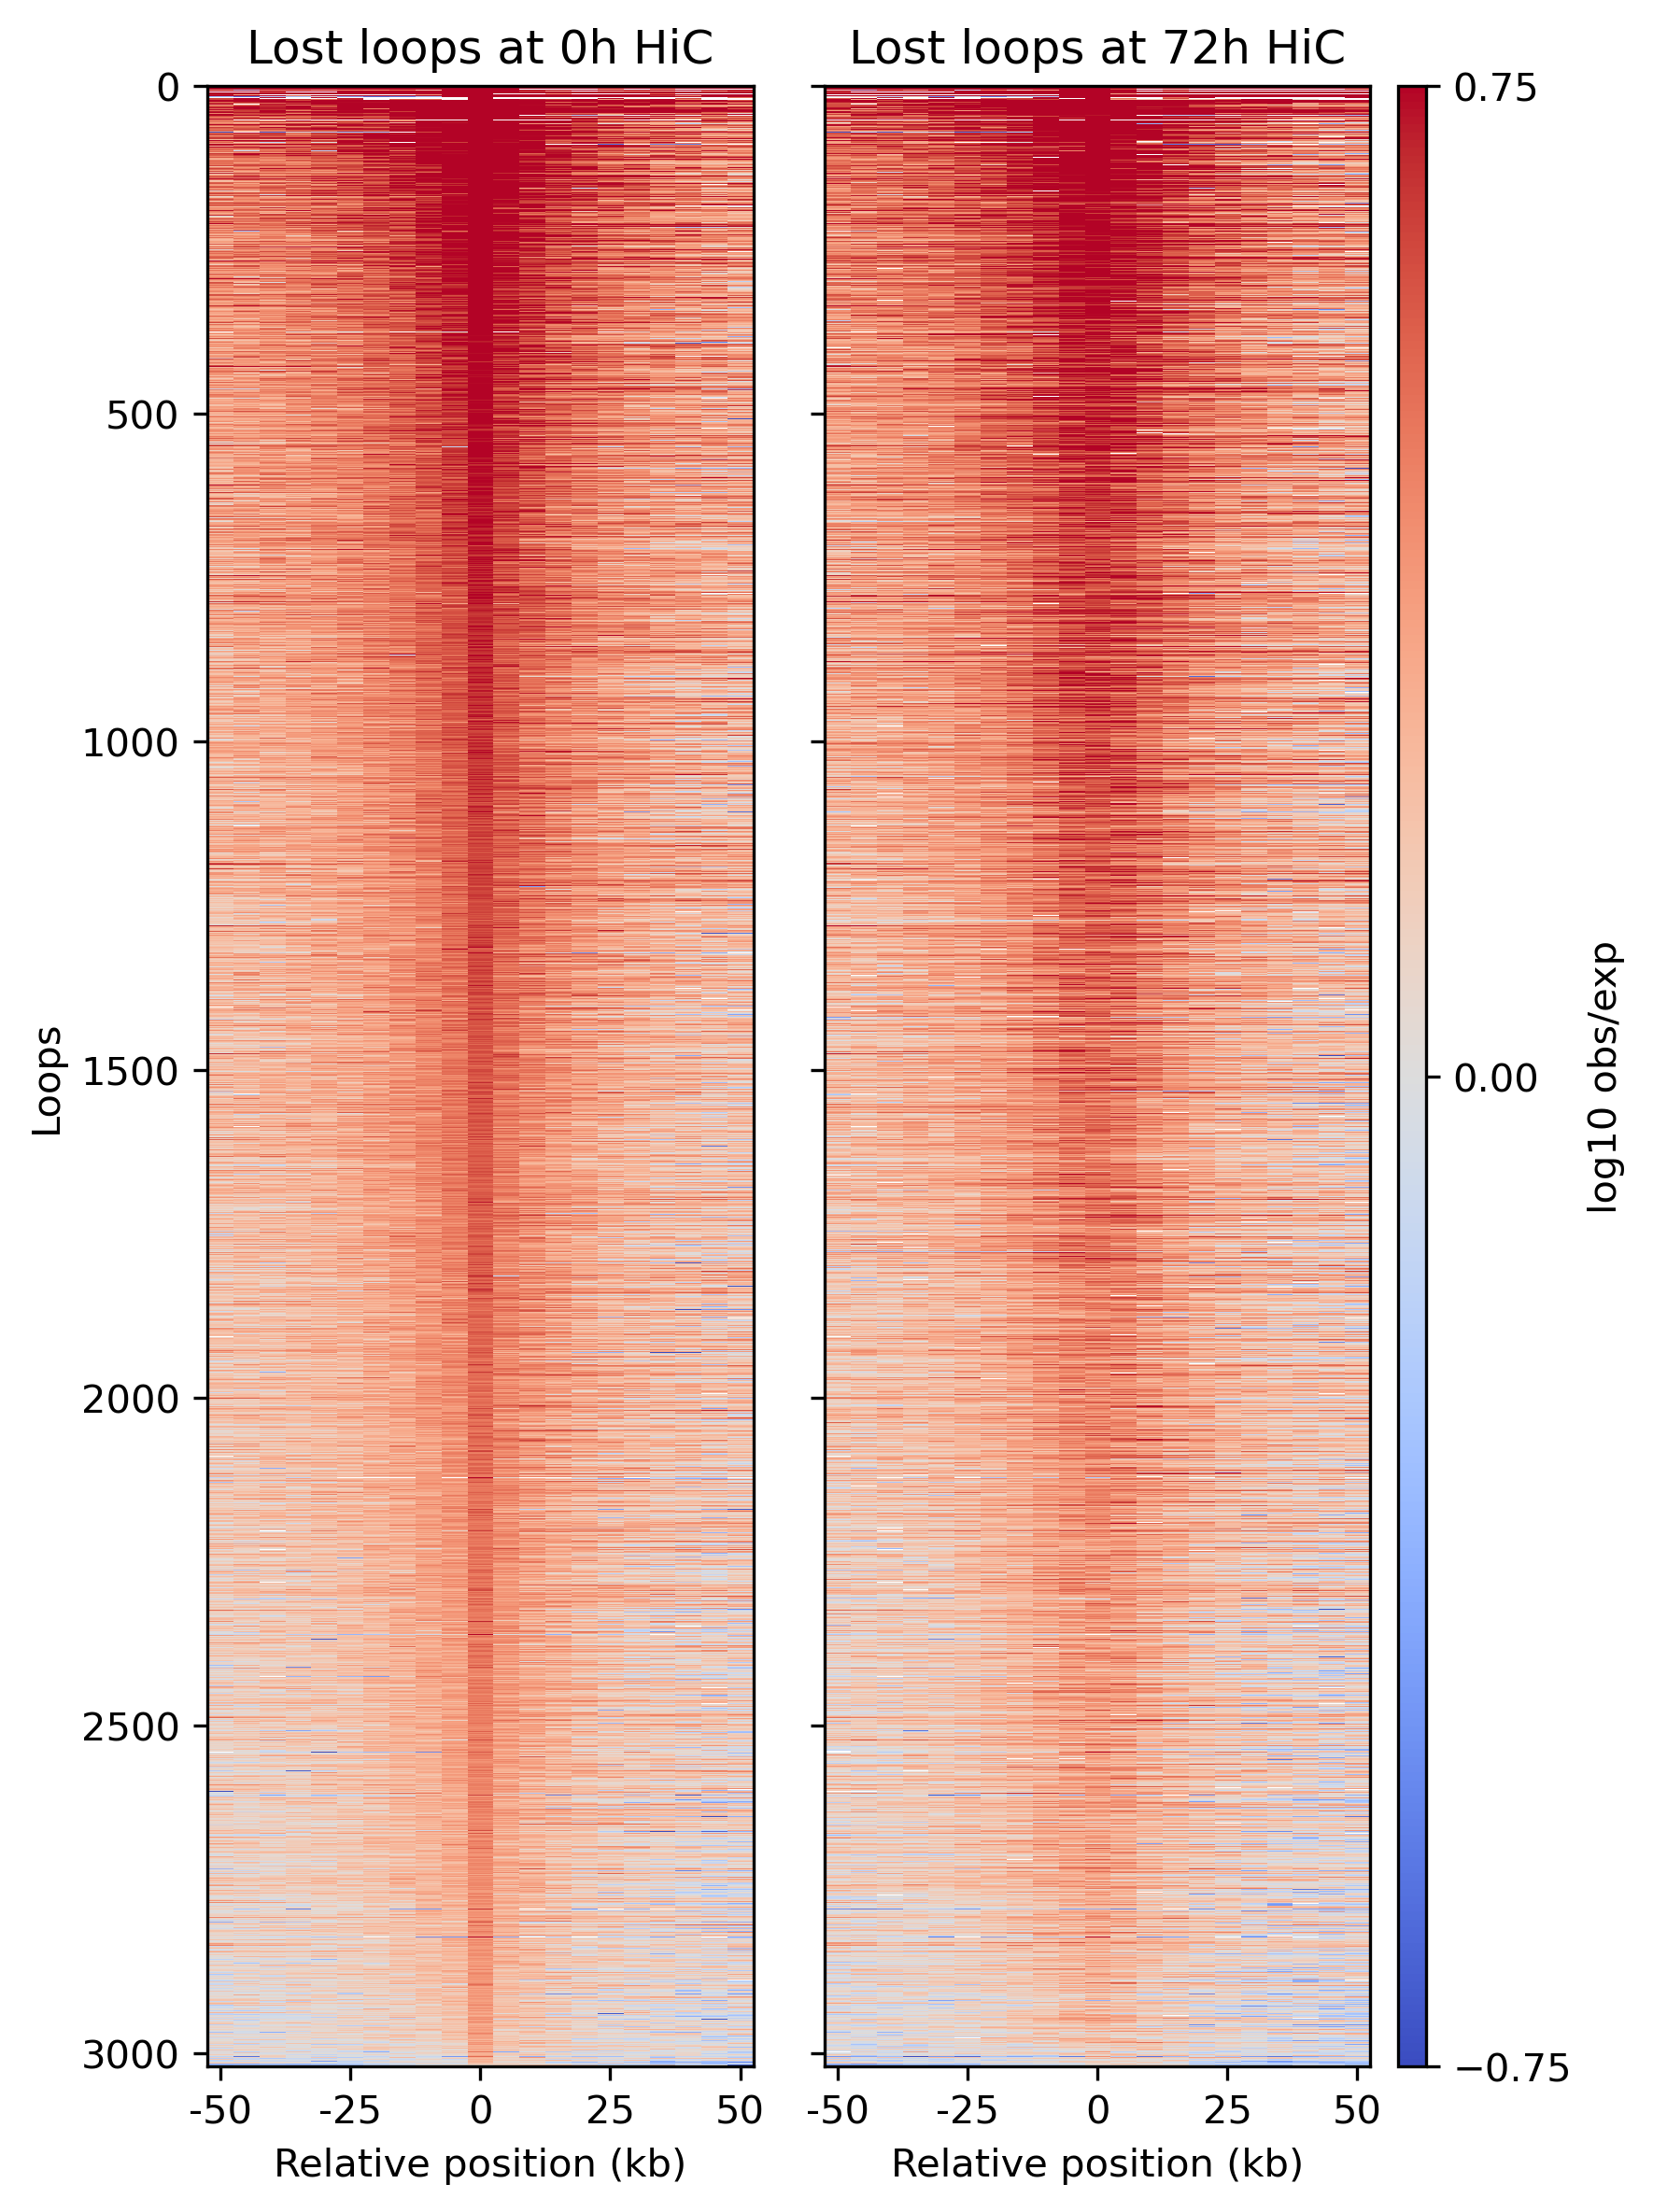

In [13]:
# Lost loops at 0h HiC (left) and 72h HiC (right) (old method)
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/'
stackup_mtx_left=dots_dir+'stackup_matrix_of_lost_loops_from_0h_to_72h_at_0h_cooler_5kb_resolution_50kb_flank.pickle'
stackup_mtx_right=dots_dir+'stackup_matrix_of_lost_loops_from_0h_to_72h_at_72h_cooler_5kb_resolution_50kb_flank.pickle'
stackup_left_title='Lost loops at 0h HiC'
stackup_right_title='Lost loops at 72h HiC'
sorted_by='left'
output_svg_filename_of_stackup='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_5/stackup_plot_of_lost_loops_from_0h_to_72h_5kb_resolution_50kb_flank_old_method.svg'

fig=create_two_stackup_plots_side_by_side(stackup_mtx_left,
                                          stackup_mtx_right,
                                          stackup_left_title,
                                          stackup_right_title,
                                          sorted_by,
                                          output_svg_filename_of_stackup=output_svg_filename_of_stackup)

/tmp/ipykernel_936737/2266495223.py:26: RuntimeWarning: divide by zero encountered in log10
  log10_mtx_left = np.log10(stackup_mtx_left)
/tmp/ipykernel_936737/2266495223.py:27: RuntimeWarning: divide by zero encountered in log10
  log10_mtx_right = np.log10(stackup_mtx_right)


Stackup plot saved to /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_4/stackup_plot_of_gained_loops_from_0h_to_72h_5kb_resolution_50kb_flank_old_method.svg


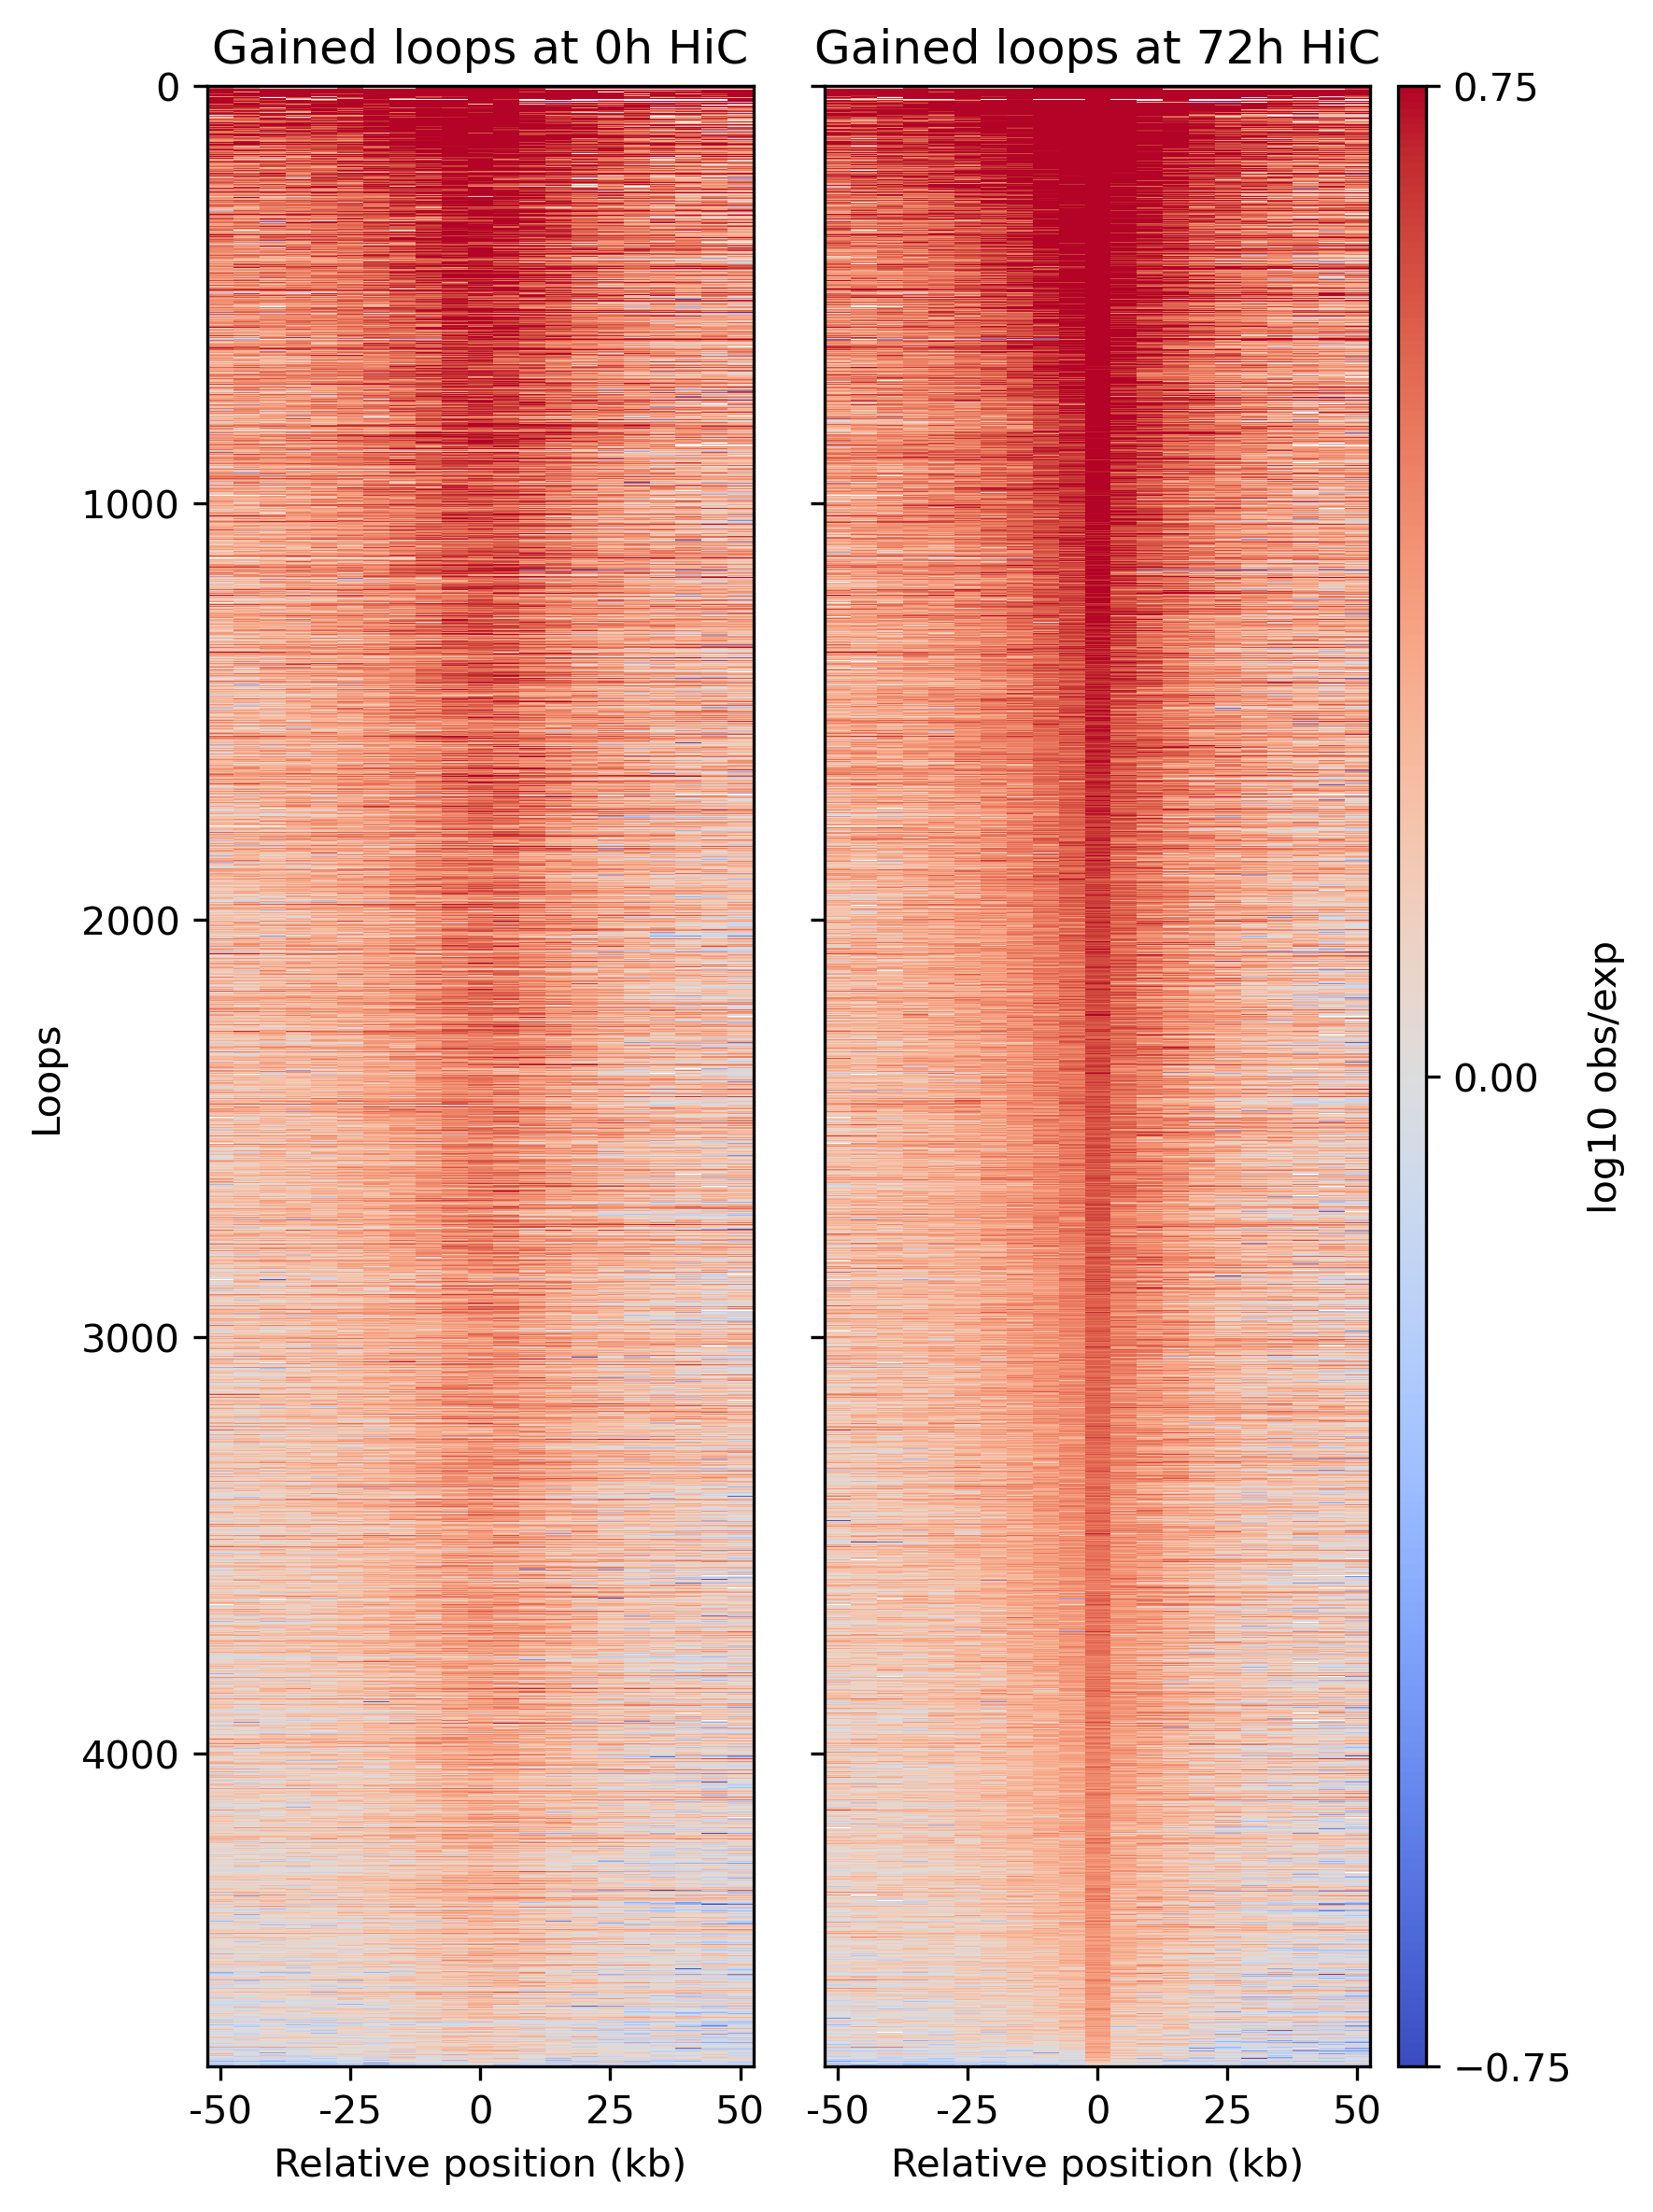

In [14]:
# gained loops at 0h HiC (left) and 72h HiC (right) (old method)
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/'
stackup_mtx_left=dots_dir+'stackup_matrix_of_gained_loops_from_0h_to_72h_at_0h_cooler_5kb_resolution_50kb_flank.pickle'
stackup_mtx_right=dots_dir+'stackup_matrix_of_gained_loops_from_0h_to_72h_at_72h_cooler_5kb_resolution_50kb_flank.pickle'
stackup_left_title='Gained loops at 0h HiC'
stackup_right_title='Gained loops at 72h HiC'
sorted_by='right'
output_svg_filename_of_stackup='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_5/stackup_plot_of_gained_loops_from_0h_to_72h_5kb_resolution_50kb_flank_old_method.svg'

fig=create_two_stackup_plots_side_by_side(stackup_mtx_left,
                                          stackup_mtx_right,
                                          stackup_left_title,
                                          stackup_right_title,
                                          sorted_by,
                                          output_svg_filename_of_stackup=output_svg_filename_of_stackup)

### Stackup plot of lost and gained loops from 0h to 72h (new method)
Only select the row of each loop in its pileup plot and stack them up

In [12]:
import numpy as np
import pandas as pd

In [17]:
dots_file='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new/results/Bond_et_al_2023_union_loop_list_5kb.tsv'
dots=pd.read_csv(dots_file, sep='\t')

# only 0h, 72h
dots_exclude_libraries=['K562_0360min','MEGA'] # remove 'MEGA', 'K562_0360min' labels
dots['sample_name']=dots['sample_name'].apply(lambda x: '&'.join(np.sort(list(set(x.split('&')) - set(dots_exclude_libraries)))))
dots=dots.loc[dots['sample_name'] != ''].reset_index(drop=True) # remove rows (with )

# lost (0h specific)
lost_dots=dots.loc[dots.sample_name == 'K562_0000min'].copy()
# gained (72h specific)
gained_dots=dots.loc[dots.sample_name == 'K562_4320min'].copy()
# static (0h and 72h)
static_dots=dots.loc[dots.sample_name == 'K562_0000min&K562_4320min'].copy()

# lost_dots.to_csv('/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new/lost_loops_from_0h_to_72h_of_Bond_et_al_2023_5kb_new_method.txt', sep='\t', index=False, header=True)
# gained_dots.to_csv('/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new/gained_loops_from_0h_to_72h_of_Bond_et_al_2023_5kb_new_method.txt', sep='\t', index=False, header=True)
# static_dots.to_csv('/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new/static_loops_from_0h_to_72h_of_Bond_et_al_2023_5kb_new_method.txt', sep='\t', index=False, header=True)


In [32]:
# lost at 0h cooler
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new/'
dots_file=dots_dir+'lost_loops_from_0h_to_72h_of_Bond_et_al_2023_5kb_new_method.txt'
# 0h cooler
cooler_file='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/coolers/HIC_K562_0000min_biorep1_to_4__hg38.hg38.mapq_30.1000.mcool'
resolution=5000
flank=50000
output=dots_dir+'stackup_matrix_of_lost_loops_from_0h_to_72h_at_0h_cooler_5kb_resolution_50kb_flank.pickle'

# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 4 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/generate_a_stackup_matrix_of_center_rows_of_pileup_plots_of_loops.py $dots_file $cooler_file $resolution $flank $output"


Job <788344> is submitted to queue <long>.


In [33]:
# lost at 72h cooler
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new/'
dots_file=dots_dir+'lost_loops_from_0h_to_72h_of_Bond_et_al_2023_5kb_new_method.txt'
# 72h cooler
cooler_file='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/coolers/HIC_K562_4320min_biorep1_to_4__hg38.hg38.mapq_30.1000.mcool'
resolution=5000
flank=50000
output=dots_dir+'stackup_matrix_of_lost_loops_from_0h_to_72h_at_72h_cooler_5kb_resolution_50kb_flank.pickle'

# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 4 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/generate_a_stackup_matrix_of_center_rows_of_pileup_plots_of_loops.py $dots_file $cooler_file $resolution $flank $output"


Job <788345> is submitted to queue <long>.


In [34]:
# gained at 0h cooler
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new/'
dots_file=dots_dir+'gained_loops_from_0h_to_72h_of_Bond_et_al_2023_5kb_new_method.txt'
# 0h cooler
cooler_file='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/coolers/HIC_K562_0000min_biorep1_to_4__hg38.hg38.mapq_30.1000.mcool'
resolution=5000
flank=50000
output=dots_dir+'stackup_matrix_of_gained_loops_from_0h_to_72h_at_0h_cooler_5kb_resolution_50kb_flank.pickle'

# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 4 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/generate_a_stackup_matrix_of_center_rows_of_pileup_plots_of_loops.py $dots_file $cooler_file $resolution $flank $output"


Job <788346> is submitted to queue <long>.


In [35]:
# gained at 72h cooler
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new/'
dots_file=dots_dir+'gained_loops_from_0h_to_72h_of_Bond_et_al_2023_5kb_new_method.txt'
# 72h cooler
cooler_file='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/coolers/HIC_K562_4320min_biorep1_to_4__hg38.hg38.mapq_30.1000.mcool'
resolution=5000
flank=50000
output=dots_dir+'stackup_matrix_of_gained_loops_from_0h_to_72h_at_72h_cooler_5kb_resolution_50kb_flank.pickle'

# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 4 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/generate_a_stackup_matrix_of_center_rows_of_pileup_plots_of_loops.py $dots_file $cooler_file $resolution $flank $output"


Job <788392> is submitted to queue <long>.


/tmp/ipykernel_936737/2266495223.py:26: RuntimeWarning: divide by zero encountered in log10
  log10_mtx_left = np.log10(stackup_mtx_left)
/tmp/ipykernel_936737/2266495223.py:27: RuntimeWarning: divide by zero encountered in log10
  log10_mtx_right = np.log10(stackup_mtx_right)


Stackup plot saved to /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_4/stackup_plot_of_lost_loops_from_0h_to_72h_5kb_resolution_50kb_flank_new_method.svg


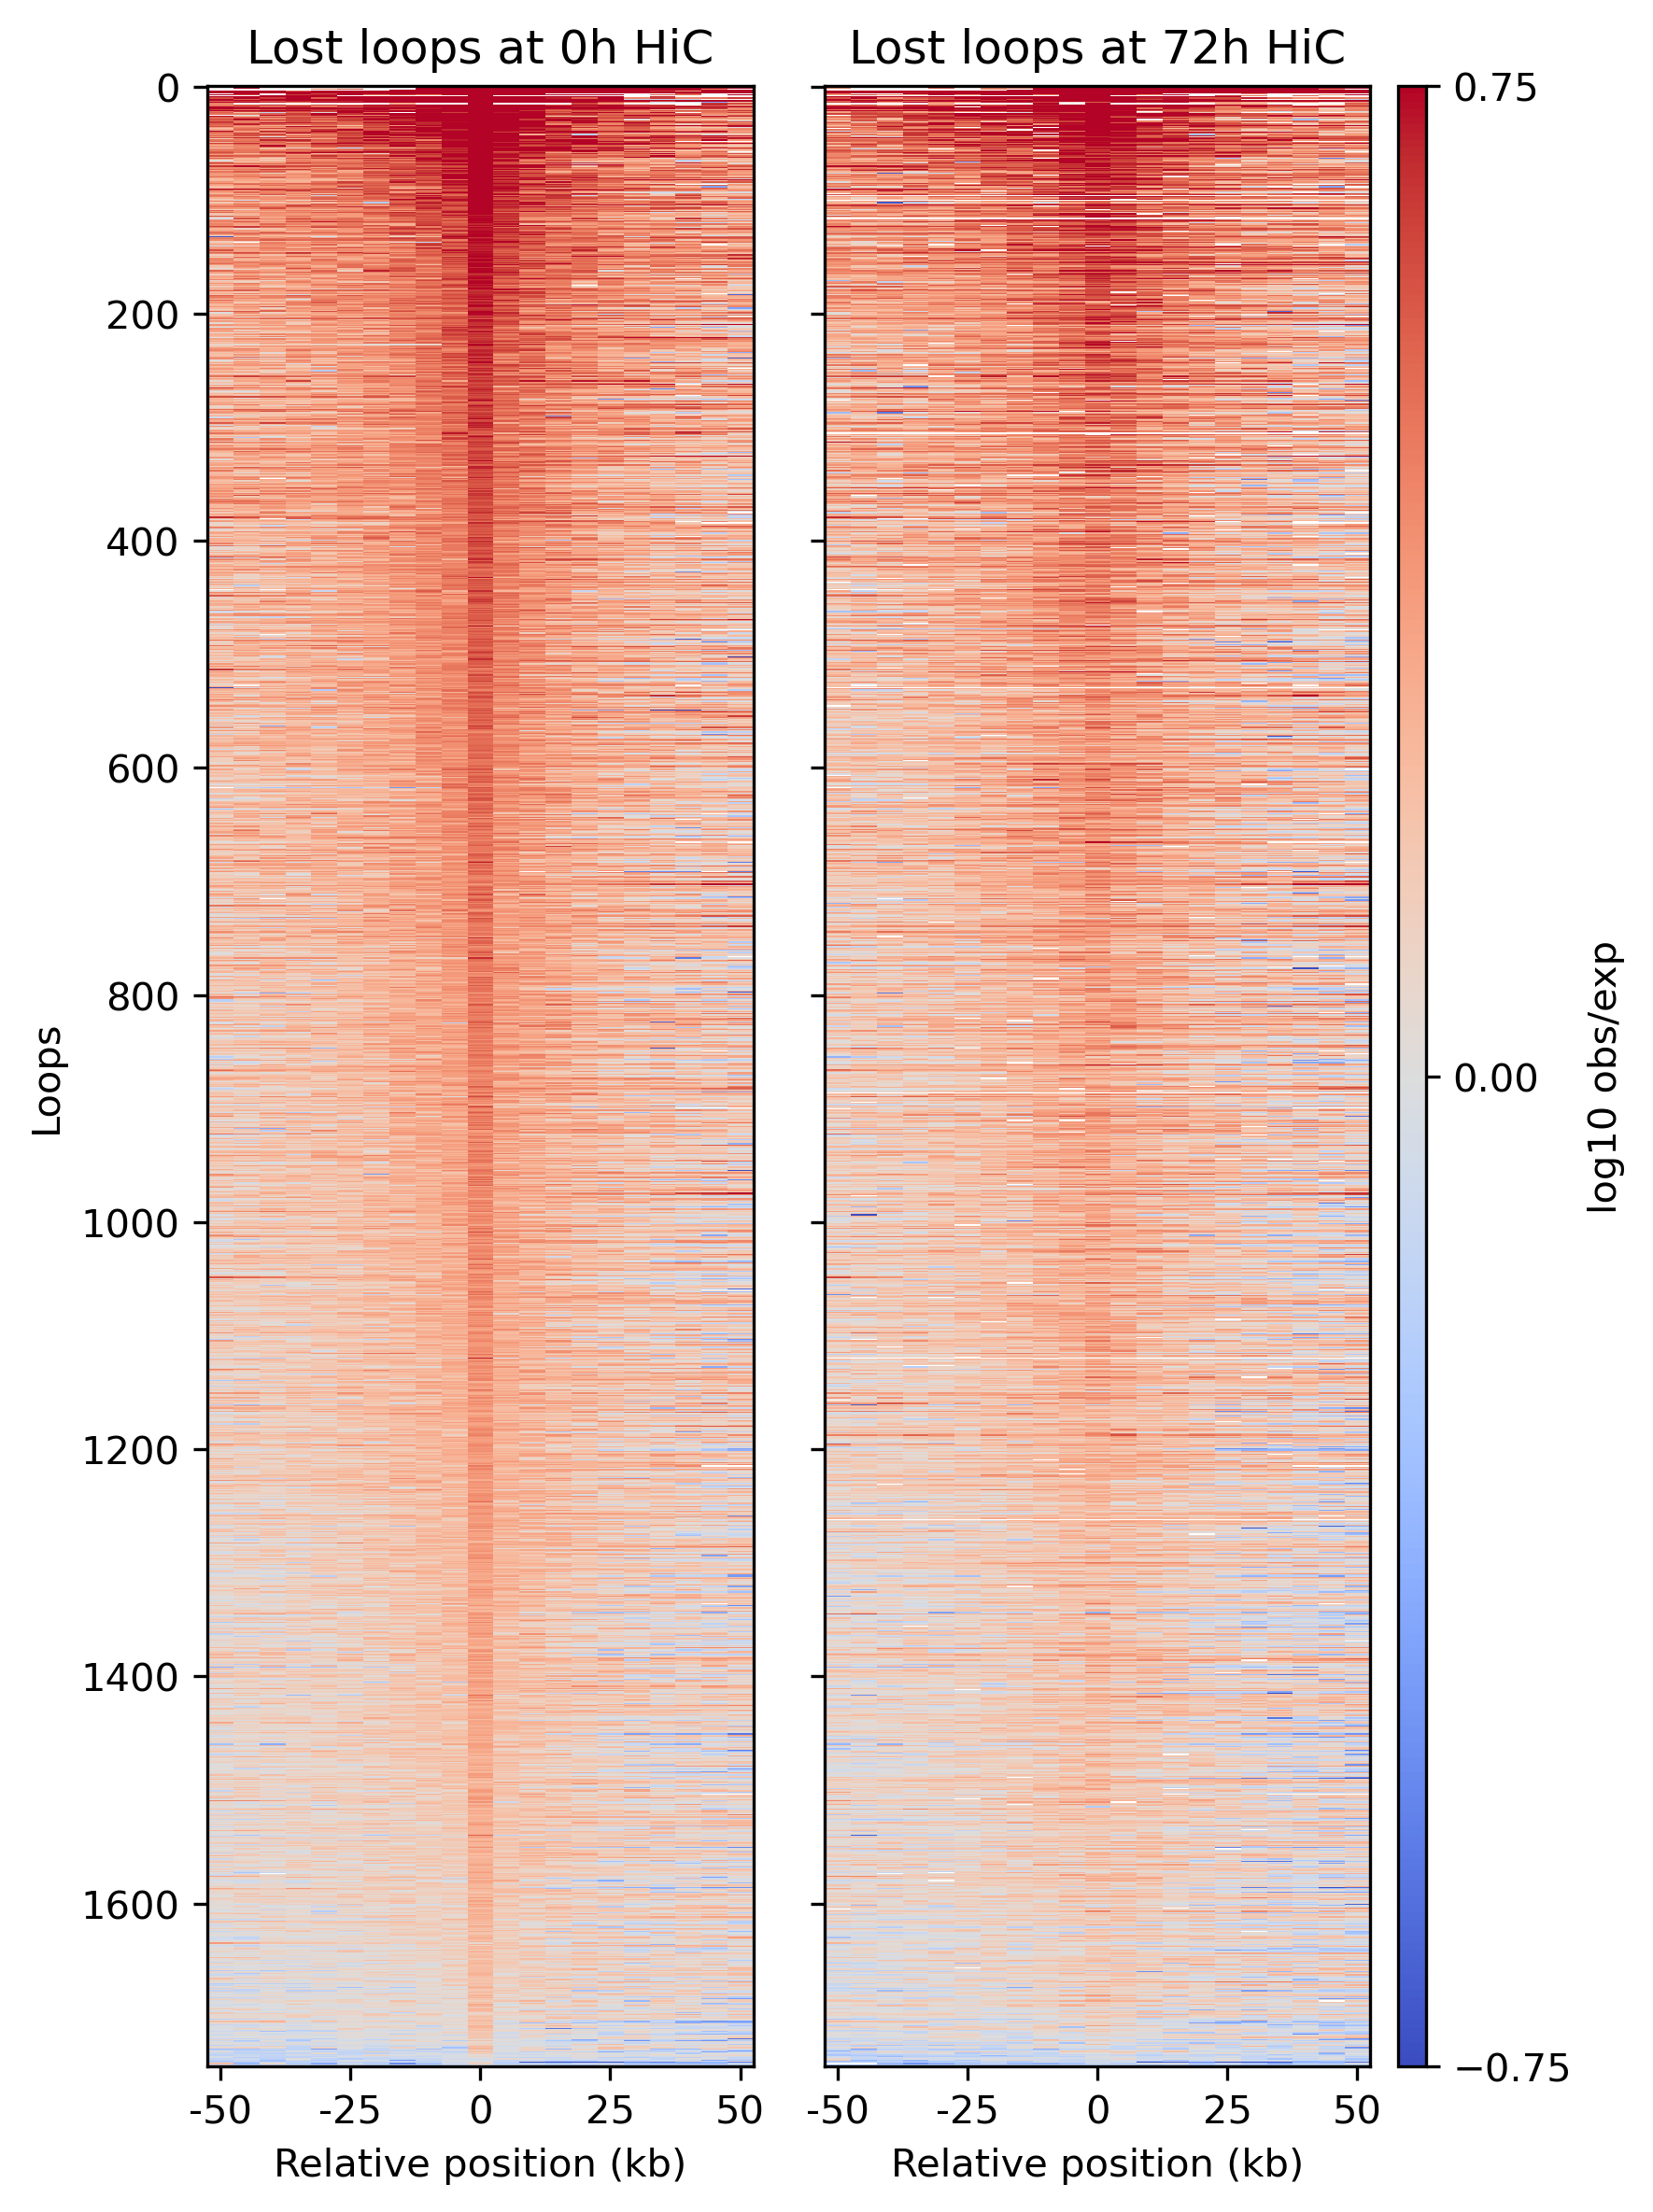

In [15]:
# Lost loops at 0h HiC (left) and 72h HiC (right) (new method)
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new/'
stackup_mtx_left=dots_dir+'stackup_matrix_of_lost_loops_from_0h_to_72h_at_0h_cooler_5kb_resolution_50kb_flank.pickle'
stackup_mtx_right=dots_dir+'stackup_matrix_of_lost_loops_from_0h_to_72h_at_72h_cooler_5kb_resolution_50kb_flank.pickle'
stackup_left_title='Lost loops at 0h HiC'
stackup_right_title='Lost loops at 72h HiC'
sorted_by='left'
output_svg_filename_of_stackup='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_5/stackup_plot_of_lost_loops_from_0h_to_72h_5kb_resolution_50kb_flank_new_method.svg'

fig=create_two_stackup_plots_side_by_side(stackup_mtx_left,
                                          stackup_mtx_right,
                                          stackup_left_title,
                                          stackup_right_title,
                                          sorted_by,
                                          output_svg_filename_of_stackup=output_svg_filename_of_stackup)

/tmp/ipykernel_936737/2266495223.py:26: RuntimeWarning: divide by zero encountered in log10
  log10_mtx_left = np.log10(stackup_mtx_left)
/tmp/ipykernel_936737/2266495223.py:27: RuntimeWarning: divide by zero encountered in log10
  log10_mtx_right = np.log10(stackup_mtx_right)


Stackup plot saved to /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_4/stackup_plot_of_gained_loops_from_0h_to_72h_5kb_resolution_50kb_flank_new_method.svg


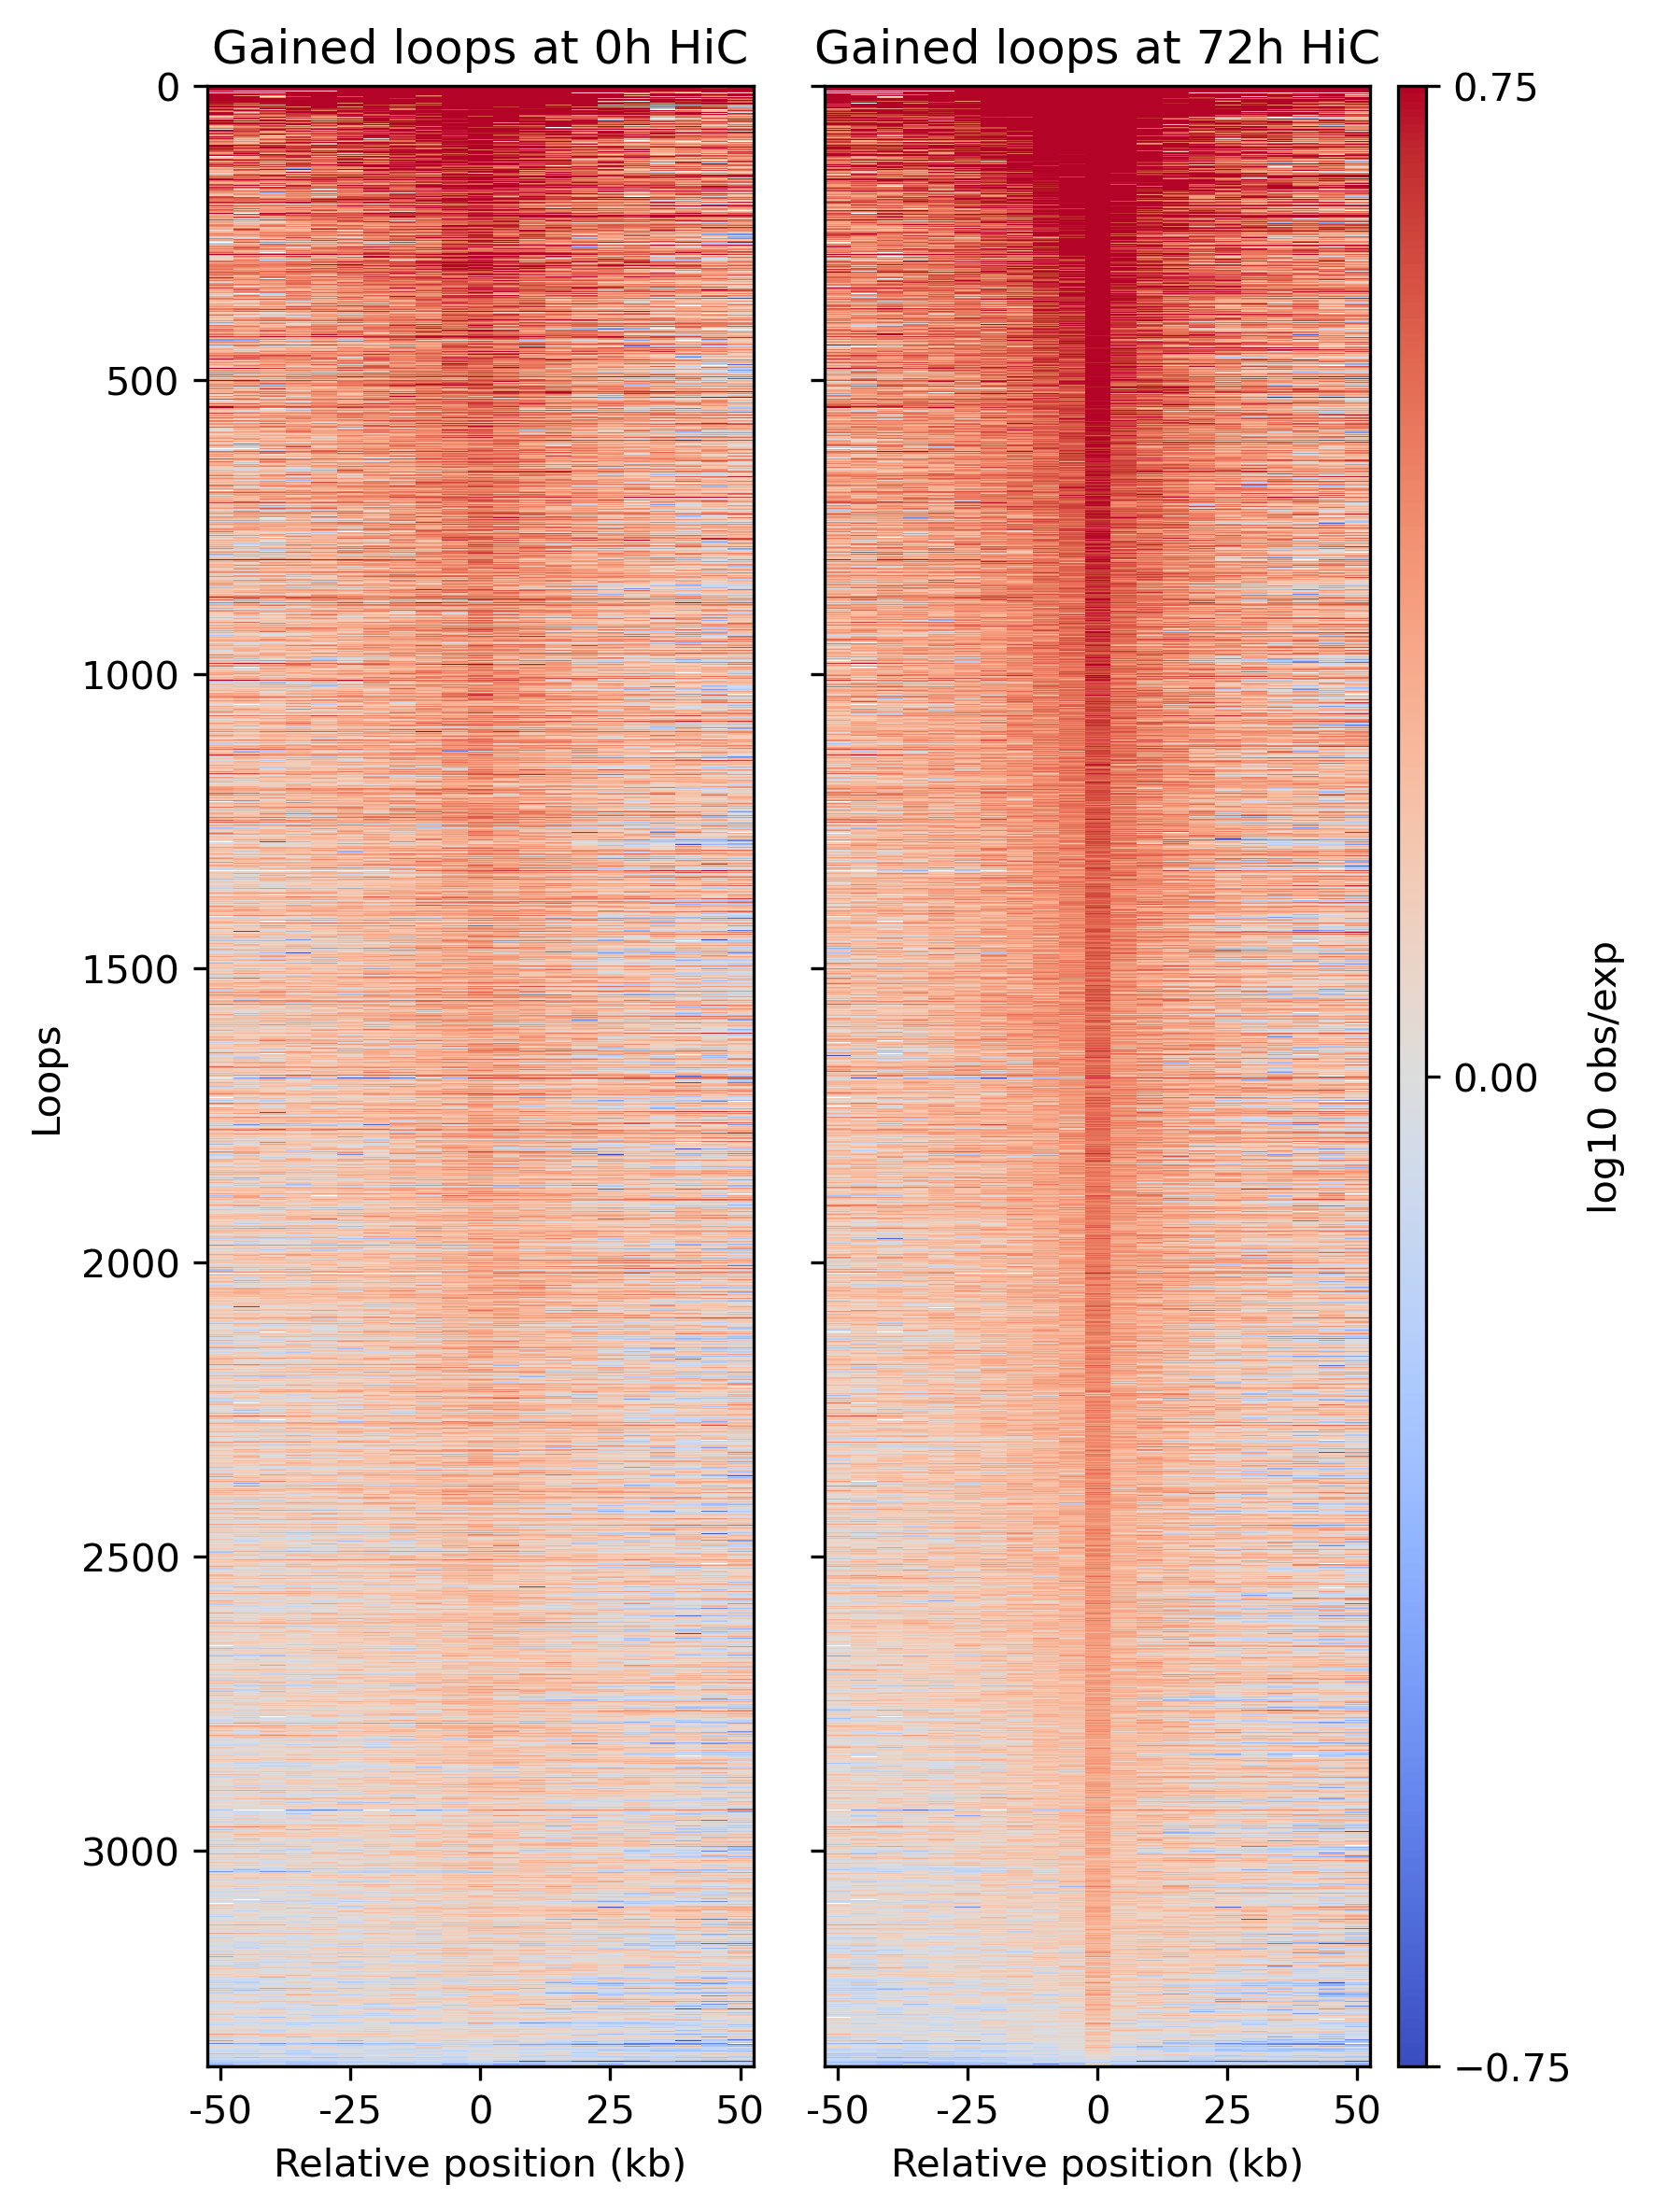

In [16]:
# gained loops at 0h HiC (left) and 72h HiC (right) (new method)
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new/'
stackup_mtx_left=dots_dir+'stackup_matrix_of_gained_loops_from_0h_to_72h_at_0h_cooler_5kb_resolution_50kb_flank.pickle'
stackup_mtx_right=dots_dir+'stackup_matrix_of_gained_loops_from_0h_to_72h_at_72h_cooler_5kb_resolution_50kb_flank.pickle'
stackup_left_title='Gained loops at 0h HiC'
stackup_right_title='Gained loops at 72h HiC'
sorted_by='right'
output_svg_filename_of_stackup='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_5/stackup_plot_of_gained_loops_from_0h_to_72h_5kb_resolution_50kb_flank_new_method.svg'

fig=create_two_stackup_plots_side_by_side(stackup_mtx_left,
                                          stackup_mtx_right,
                                          stackup_left_title,
                                          stackup_right_title,
                                          sorted_by,
                                          output_svg_filename_of_stackup=output_svg_filename_of_stackup)

## Updated: Use DESeq2 to identify lost and gained loops using UnionLoops-defined lost and gained loops from 0 and 72 hour.
~ replicate + condition <br>
paired samples <br>
Controls for per-replicate variation before testing for condition differences. <br>
Useful if replicate 1 in 0h is biologically linked to replicate 1 in 72h. <br>

### Generate count matrix of each biorep at 0h and 72h

In [ ]:
# !bsub -q "long" -W 20:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 1 -R "rusage[mem=64G]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/Bond_et_al_2023/generate_counts_of_each_biorep_of_HiC_for_loops_from_0_and_72h_5kb_resolution_new_method.py"


### Perform DESeq2 between 0 and 72 hour using four bioreps (R, local laptop)

In [ ]:
# /home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new/counts_of_each_biorep_of_HiC_for_loops_from_0_and_72h_5kb_resolution_new_method.tsv

library(DESeq2)
library(tibble)

# Load raw counts
countData_df <- read.table("counts_of_each_biorep_of_HiC_for_loops_from_0_and_72h_5kb_resolution_new_method.tsv", header = T)
countData_df <- countData_df[countData_df$status == 'lost' | countData_df$status == 'gained', ]

countData <- countData_df[, c(paste0('K562_0000min', c('_R1_count','_R2_count','_R3_count','_R4_count')), paste0('K562_4320min', c('_R1_count','_R2_count','_R3_count','_R4_count')))]
rownames(countData) <- paste0('loop', seq(1,nrow(countData)))
colData <- data.frame(condition = factor(rep(c("0h", "72h"), each = 4)),
                      replicate = factor(rep(1:4, 2)),
                      row.names = colnames(countData))

## Ensure the colnames of the count matrix is equal to the rownames of the colData
all(colnames(countData) == rownames(colData))

# paired samples
# Controls for per-replicate variation before testing for condition differences.
# Useful if replicate 1 in 0h is biologically linked to replicate 1 in 72h.
dds <- DESeqDataSetFromMatrix(
  countData = countData,
  colData = colData,
  design = ~ replicate + condition
)

dds$condition <- relevel(dds$condition, ref = "0h")
# Run DESeq2
dds <- DESeq(dds)
## Get shrunken results
results <- lfcShrink(dds,
                 coef = "condition_72h_vs_0h",
                 type = "apeglm")
# using 'apeglm' for LFC shrinkage. If used in published research, please cite:
#   Zhu, A., Ibrahim, J.G., Love, M.I. (2018) Heavy-tailed prior distributions for
# sequence count data: removing the noise and preserving large differences.
# Bioinformatics. https://doi.org/10.1093/bioinformatics/bty895

output_df <- as.data.frame(results)
output_df <- cbind(countData_df, results)
# label deseq2 results
output_df$deseq2_status <- ifelse(
  !is.na(output_df$padj) & output_df$padj < 0.05 & output_df$log2FoldChange > 0, "gained",
  ifelse(!is.na(output_df$padj) & output_df$padj < 0.05 & output_df$log2FoldChange < 0, "lost", "insig")
)

# write.table(output_df, 'DESeq2_results_of_lost_and_gained_loops_from_0_and_72h_5kb_resolution_new_method.txt', sep="\t", quote = FALSE, row.names = FALSE)
# saved to /home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new/DESeq2_results_of_lost_and_gained_loops_from_0_and_72h_5kb_resolution_new_method.txt


# For all UnionLoops-defined lost loops (1744)
sum(output_df$status == 'lost')
# 1744
table(output_df[output_df$status == 'lost','deseq2_status'])
# insig  lost 
# 1716    28 
# No gained
round(sum(output_df$status == 'lost' & output_df$deseq2_status == 'lost')/sum(output_df$status == 'lost') * 100, 2)
# 1.61%
100 - round(sum(output_df$status == 'lost' & output_df$deseq2_status == 'lost')/sum(output_df$status == 'lost') * 100, 2)
# 98.39%

# For all UnionLoops-defined gained loops (3368)
sum(output_df$status == 'gained')
# 3368
table(output_df[output_df$status == 'gained','deseq2_status'])
# gained  insig s
# 11   3357 
# No lost
round(sum(output_df$status == 'gained' & output_df$deseq2_status == 'gained')/sum(output_df$status == 'gained') * 100, 2)
# 0.33%
100 - round(sum(output_df$status == 'gained' & output_df$deseq2_status == 'gained')/sum(output_df$status == 'gained') * 100, 2)
# 99.67%




# > sessionInfo()
# R version 4.1.1 (2021-08-10)
# Platform: x86_64-apple-darwin17.0 (64-bit)
# Running under: macOS Monterey 12.7.6
# 
# Matrix products: default
# LAPACK: /Library/Frameworks/R.framework/Versions/4.1/Resources/lib/libRlapack.dylib
# 
# locale:
#   [1] en_US.UTF-8/en_US.UTF-8/en_US.UTF-8/C/en_US.UTF-8/en_US.UTF-8
# 
# attached base packages:
#   [1] stats4    stats     graphics  grDevices utils     datasets  methods   base     
# 
# other attached packages:
#   [1] tibble_3.2.1                DESeq2_1.34.0               SummarizedExperiment_1.24.0 Biobase_2.54.0             
# [5] MatrixGenerics_1.6.0        matrixStats_1.5.0           GenomicRanges_1.46.1        GenomeInfoDb_1.30.1        
# [9] IRanges_2.28.0              S4Vectors_0.32.4            BiocGenerics_0.40.0        
# 
# loaded via a namespace (and not attached):
#   [1] bdsmatrix_1.3-7        Rcpp_1.1.0             locfit_1.5-9.12        mvtnorm_1.1-3          apeglm_1.16.0         
# [6] lattice_0.22-7         png_0.1-8              Biostrings_2.62.0      utf8_1.2.4             plyr_1.8.9            
# [11] R6_2.6.1               emdbook_1.3.14         coda_0.19-4.1          RSQLite_2.4.2          httr_1.4.7            
# [16] ggplot2_3.5.0          pillar_1.9.0           zlibbioc_1.40.0        rlang_1.1.6            rstudioapi_0.17.1     
# [21] annotate_1.72.0        blob_1.2.4             Matrix_1.3-4           bbmle_1.0.25.1         splines_4.1.1         
# [26] BiocParallel_1.28.3    geneplotter_1.72.0     RCurl_1.98-1.17        bit_4.6.0              DelayedArray_0.20.0   
# [31] numDeriv_2016.8-1.1    compiler_4.1.1         pkgconfig_2.0.3        tidyselect_1.2.1       KEGGREST_1.34.0       
# [36] GenomeInfoDbData_1.2.7 XML_3.99-0.16.1        fansi_1.0.6            crayon_1.5.3           dplyr_1.1.4           
# [41] MASS_7.3-60.0.1        bitops_1.0-9           grid_4.1.1             xtable_1.8-4           gtable_0.3.6          
# [46] lifecycle_1.0.4        DBI_1.2.3              magrittr_2.0.3         scales_1.4.0           cli_3.6.5             
# [51] cachem_1.1.0           farver_2.1.2           XVector_0.34.0         genefilter_1.76.0      vctrs_0.6.5           
# [56] generics_0.1.4         RColorBrewer_1.1-3     tools_4.1.1            dichromat_2.0-0.1      bit64_4.6.0-1         
# [61] glue_1.8.0             parallel_4.1.1         fastmap_1.2.0          survival_3.5-8         AnnotationDbi_1.56.2  
# [66] colorspace_2.1-1       memoise_2.0.1 


## Perform Kmeans clustering on z-scored loop strength across three time points of those static loops and MEGA-only loops, respectively (5kb, new method).

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans

In [11]:
dots_file='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new/results/Bond_et_al_2023_union_loop_list_5kb.tsv'
dots=pd.read_csv(dots_file, sep='\t')

static=dots.loc[(dots.sample_name.str.contains('K562_0000min')) & (dots.sample_name.str.contains('K562_0360min')) & (dots.sample_name.str.contains('K562_4320min')), ['K562_0000min','K562_0360min','K562_4320min']]
# Z-score per row
z_static = static.sub(static.mean(axis=1), axis=0).div(static.std(axis=1), axis=0)

In [12]:
len(z_static) # number of static loops

4265

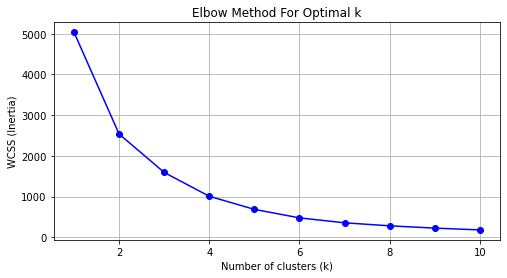

In [13]:
# Elbow method to find optimal k
wcss = []
k_values = range(1, 11)

data=z_static.to_numpy()

for k in k_values:
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300,
                    n_init=10, random_state=42)
    kmeans.fit(data)
    wcss.append(kmeans.inertia_)

# Step 3: Plot the elbow curve
plt.figure(figsize=(8, 4))
plt.plot(k_values, wcss, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method For Optimal k')
plt.grid(True)

# To determine the optimal number of clusters (k) in K-Means clustering, 
# the Elbow Method helps by plotting the Within-Cluster Sum of Squares (WCSS)
# against a range of k values. You choose k at the "elbow" point — where WCSS
# starts decreasing more slowly.

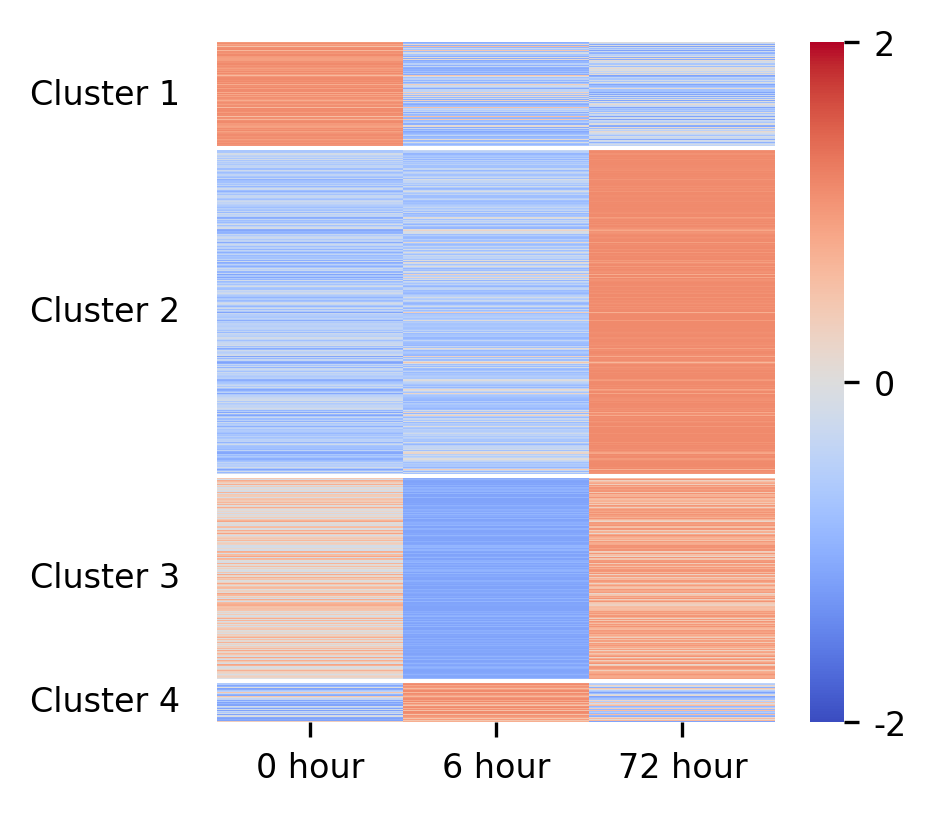

In [15]:
data=z_static.to_numpy()
# Perform KMeans clustering on rows
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=11)
row_labels = kmeans.fit_predict(data)

# Sort the data by cluster labels
sorted_idx = np.argsort(row_labels)
sorted_data = data[sorted_idx]
sorted_labels = row_labels[sorted_idx]

column_labels = ['0 hour', '6 hour', '72 hour']

plt.figure(figsize=(3, 3), dpi=300)
ax = sns.heatmap(sorted_data, cmap='coolwarm',
                 vmax=2, vmin=-2,
                 cbar=True, yticklabels=False, xticklabels=column_labels)

# Set font size of x-axis tick labels
ax.set_xticklabels(column_labels, fontsize=8)

# Set colorbar ticks to -2, 0, and 2
colorbar = ax.collections[0].colorbar
colorbar.set_ticks([-2, 0, 2])
colorbar.set_ticklabels(['-2', '0', '2'])
colorbar.ax.tick_params(labelsize=8)  # Set colorbar tick label font size

# Add horizontal lines for ROW cluster boundaries
row_boundaries = np.where(np.diff(sorted_labels) != 0)[0] + 1
for b in row_boundaries:
    plt.axhline(b, color='white', linewidth=1)
    
# Annotate ROW clusters
row_cluster_boundaries = np.r_[0, row_boundaries, len(sorted_labels)]
for i in range(len(row_cluster_boundaries) - 1):
    start = row_cluster_boundaries[i]
    end = row_cluster_boundaries[i + 1]
    mid = (start + end) // 2
    cluster_idx = sorted_labels[mid]
    ax.text(-0.2, mid, f'Cluster {cluster_idx+1}', va='center', ha='right', 
            fontsize=8, color='k')
    
# # save svg
# plt.savefig(f"/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_S5/heatmap_of_rowwise_z_scored_loop_strength_of_k_means_clustered_static_loops_5kb_new_method_Bond_et_al_2023.svg", format='svg', bbox_inches='tight')
